In [ ]:
# =========================
# PART 1: YELP REVIEW POLARITY - TEXTRANK EXTRACTIVE SUMMARISATION
# 1, 3, 5, 7 sentence summaries
# Predefined train/test + stratified validation split from train
# Save outputs to Google Drive
# =========================

!pip install -q pandas numpy nltk scikit-learn rouge-score networkx

import os
import re
import time
import json
import numpy as np
import pandas as pd
import nltk
import networkx as nx

from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from rouge_score import rouge_scorer

from google.colab import drive
drive.mount('/content/drive')

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

# =========================
# 1. PATHS / CONFIG
# =========================
TRAIN_PATH = "/content/drive/MyDrive/yelp_review_polarity_csv/train.csv"
TEST_PATH = "/content/drive/MyDrive/yelp_review_polarity_csv/test.csv"
OUTPUT_DIR = "/content/drive/MyDrive/yelp_textrank_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

SEED = 42
VAL_SIZE = 0.1
SUMMARY_SENTENCE_COUNTS = [1, 3, 5, 7]
CHECKPOINT_EVERY = 5000
EVAL_SAMPLE_SIZE = None   # set e.g. 2000 for faster eval if needed

print("Output folder:", OUTPUT_DIR)

# =========================
# 2. LOAD DATASET
# =========================
train_df = pd.read_csv(TRAIN_PATH, header=None, names=["label", "text"])
test_df = pd.read_csv(TEST_PATH, header=None, names=["label", "text"])

print("Original shapes:")
print("train.csv:", train_df.shape)
print("test.csv :", test_df.shape)

# Original labels: 1=negative, 2=positive
label_map = {1: 0, 2: 1}
train_df["label"] = train_df["label"].map(label_map)
test_df["label"] = test_df["label"].map(label_map)

# =========================
# 3. PREPROCESSING
# =========================
def clean_text(text):
    text = str(text)
    text = text.replace("<br />", " ")
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

train_df["text"] = train_df["text"].astype(str).apply(clean_text)
test_df["text"] = test_df["text"].astype(str).apply(clean_text)

train_df = train_df[train_df["text"].str.len() > 0].reset_index(drop=True)
test_df = test_df[test_df["text"].str.len() > 0].reset_index(drop=True)

print("\nAfter cleaning:")
print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

# =========================
# 4. STRATIFIED VALIDATION SPLIT
# =========================
train_split_df, val_df = train_test_split(
    train_df,
    test_size=VAL_SIZE,
    stratify=train_df["label"],
    random_state=SEED,
)

train_split_df = train_split_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("\nSplit sizes:")
print("Train:", len(train_split_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

print("\nLabel distributions:")
print("Train:\n", train_split_df["label"].value_counts(normalize=True).sort_index())
print("Val:\n", val_df["label"].value_counts(normalize=True).sort_index())
print("Test:\n", test_df["label"].value_counts(normalize=True).sort_index())

# Save exact splits used
train_split_df.to_csv(os.path.join(OUTPUT_DIR, "train_split_used.csv"), index=False)
val_df.to_csv(os.path.join(OUTPUT_DIR, "val_split_used.csv"), index=False)
test_df.to_csv(os.path.join(OUTPUT_DIR, "test_split_used.csv"), index=False)

# =========================
# 5. TEXTRANK SUMMARY FUNCTION
# =========================
def textrank_summaries_all(text, ks=[1, 3, 5, 7]):
    sentences = sent_tokenize(str(text))

    if len(sentences) == 0:
        return {k: "" for k in ks}

    if len(sentences) == 1:
        return {k: sentences[0] for k in ks}

    try:
        vectorizer = TfidfVectorizer(stop_words="english")
        X = vectorizer.fit_transform(sentences)

        if X.shape[0] < 2 or X.shape[1] < 2:
            return {k: " ".join(sentences[:min(k, len(sentences))]) for k in ks}

        similarity_matrix = cosine_similarity(X)
        np.fill_diagonal(similarity_matrix, 0)

        graph = nx.from_numpy_array(similarity_matrix)
        scores = nx.pagerank(graph)

        ranked_indices = sorted(scores.keys(), key=lambda i: scores[i], reverse=True)

        results = {}
        for k in ks:
            top_k = ranked_indices[:min(k, len(sentences))]
            top_k_sorted = sorted(top_k)
            results[k] = " ".join([sentences[i] for i in top_k_sorted])

        return results

    except Exception:
        return {k: " ".join(sentences[:min(k, len(sentences))]) for k in ks}

# =========================
# 6. CHECKPOINT HELPERS
# =========================
def get_checkpoint_path(split_name):
    return os.path.join(OUTPUT_DIR, f"{split_name}_textrank_checkpoint.json")

def get_partial_csv_path(split_name, k):
    return os.path.join(OUTPUT_DIR, f"{split_name}_textrank_{k}_sentences_partial.csv")

def save_checkpoint(split_name, idx, summaries_dict, labels):
    checkpoint = {
        "last_completed_index": idx
    }
    with open(get_checkpoint_path(split_name), "w") as f:
        json.dump(checkpoint, f)

    for k, summaries in summaries_dict.items():
        partial_df = pd.DataFrame({
            "summary_text": summaries,
            "label": labels[:len(summaries)]
        })
        partial_df.to_csv(get_partial_csv_path(split_name, k), index=False)

def load_checkpoint(split_name):
    checkpoint_path = get_checkpoint_path(split_name)
    if not os.path.exists(checkpoint_path):
        return -1, {1: [], 3: [], 5: [], 7: []}

    with open(checkpoint_path, "r") as f:
        checkpoint = json.load(f)

    summaries_dict = {}
    for k in SUMMARY_SENTENCE_COUNTS:
        partial_path = get_partial_csv_path(split_name, k)
        if os.path.exists(partial_path):
            temp_df = pd.read_csv(partial_path)
            summaries_dict[k] = temp_df["summary_text"].tolist()
        else:
            summaries_dict[k] = []

    return checkpoint["last_completed_index"], summaries_dict

# =========================
# 7. GENERATE SUMMARIES
# =========================
def generate_split_summaries(texts, labels, split_name):
    last_completed_index, summaries_dict = load_checkpoint(split_name)
    start_idx = last_completed_index + 1

    if start_idx > 0:
        print(f"\nResuming {split_name} from index {start_idx}...")

    start_time = time.time()

    for i in range(start_idx, len(texts)):
        result = textrank_summaries_all(texts[i], ks=SUMMARY_SENTENCE_COUNTS)

        for k in SUMMARY_SENTENCE_COUNTS:
            summaries_dict[k].append(result[k])

        if (i + 1) % CHECKPOINT_EVERY == 0:
            save_checkpoint(split_name, i, summaries_dict, labels)
            print(f"{split_name}: checkpoint saved at {i+1}/{len(texts)}")

    generation_time = time.time() - start_time

    final_dfs = {}
    for k in SUMMARY_SENTENCE_COUNTS:
        out_df = pd.DataFrame({
            "summary_text": summaries_dict[k],
            "label": labels
        })
        save_path = os.path.join(OUTPUT_DIR, f"{split_name}_textrank_{k}_sentences.csv")
        out_df.to_csv(save_path, index=False)
        final_dfs[k] = out_df
        print(f"Saved: {save_path}")

    save_checkpoint(split_name, len(texts) - 1, summaries_dict, labels)

    print(f"\n{split_name} generation time: {generation_time:.2f} sec")
    return final_dfs, generation_time

# =========================
# 8. RUN SUMMARY GENERATION
# =========================
train_texts = train_split_df["text"].tolist()
val_texts = val_df["text"].tolist()
test_texts = test_df["text"].tolist()

train_labels = train_split_df["label"].tolist()
val_labels = val_df["label"].tolist()
test_labels = test_df["label"].tolist()

train_summaries, train_time = generate_split_summaries(train_texts, train_labels, "train")
val_summaries, val_time = generate_split_summaries(val_texts, val_labels, "val")
test_summaries, test_time = generate_split_summaries(test_texts, test_labels, "test")

# =========================
# 9. SHOW SAMPLE OUTPUT
# =========================
if len(train_texts) > 0:
    print("\n================ SAMPLE ================\n")
    print("Original text:\n")
    print(train_texts[0][:800])

    for k in SUMMARY_SENTENCE_COUNTS:
        print(f"\n{k}-sentence summary:\n")
        print(train_summaries[k].iloc[0]['summary_text'][:800])

# =========================
# 10. EVALUATION
# =========================
def evaluate_extractive_summaries(original_texts, summary_texts, dataset_name):
    original_word_counts = []
    summary_word_counts = []
    original_sentence_counts = []
    summary_sentence_counts = []

    rouge1_scores = []
    rouge2_scores = []
    rougel_scores = []
    bleu_scores = []

    scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
    smoothie = SmoothingFunction().method1

    if EVAL_SAMPLE_SIZE is not None and len(original_texts) > EVAL_SAMPLE_SIZE:
        rng = np.random.default_rng(SEED)
        idx = rng.choice(len(original_texts), size=EVAL_SAMPLE_SIZE, replace=False)
        original_eval = [original_texts[i] for i in idx]
        summary_eval = [summary_texts[i] for i in idx]
    else:
        original_eval = original_texts
        summary_eval = list(summary_texts)

    for original, summary in zip(original_eval, summary_eval):
        original = str(original)
        summary = str(summary)

        orig_words = len(word_tokenize(original))
        summ_words = len(word_tokenize(summary))
        orig_sents = len(sent_tokenize(original))
        summ_sents = len(sent_tokenize(summary))

        original_word_counts.append(orig_words)
        summary_word_counts.append(summ_words)
        original_sentence_counts.append(orig_sents)
        summary_sentence_counts.append(summ_sents)

        try:
            scores = scorer.score(original, summary)
            rouge1_scores.append(scores["rouge1"].fmeasure)
            rouge2_scores.append(scores["rouge2"].fmeasure)
            rougel_scores.append(scores["rougeL"].fmeasure)
        except Exception:
            rouge1_scores.append(np.nan)
            rouge2_scores.append(np.nan)
            rougel_scores.append(np.nan)

        try:
            reference = [word_tokenize(original)]
            candidate = word_tokenize(summary)
            bleu = sentence_bleu(reference, candidate, smoothing_function=smoothie)
            bleu_scores.append(bleu)
        except Exception:
            bleu_scores.append(np.nan)

    avg_original_words = np.mean(original_word_counts)
    avg_summary_words = np.mean(summary_word_counts)
    avg_original_sentences = np.mean(original_sentence_counts)
    avg_summary_sentences = np.mean(summary_sentence_counts)

    word_compression_ratio = avg_summary_words / avg_original_words if avg_original_words > 0 else np.nan
    sentence_compression_ratio = avg_summary_sentences / avg_original_sentences if avg_original_sentences > 0 else np.nan

    result = {
        "dataset": dataset_name,
        "avg_original_words": round(avg_original_words, 2),
        "avg_summary_words": round(avg_summary_words, 2),
        "avg_original_sentences": round(avg_original_sentences, 2),
        "avg_summary_sentences": round(avg_summary_sentences, 2),
        "word_compression_ratio": round(word_compression_ratio, 4),
        "sentence_compression_ratio": round(sentence_compression_ratio, 4),
        "rouge_1": round(np.nanmean(rouge1_scores), 4),
        "rouge_2": round(np.nanmean(rouge2_scores), 4),
        "rouge_L": round(np.nanmean(rougel_scores), 4),
        "bleu": round(np.nanmean(bleu_scores), 4),
    }

    print("\n================================")
    print("EVALUATION:", dataset_name)
    print("================================")
    for k, v in result.items():
        if k != "dataset":
            print(f"{k}: {v}")

    return result

# =========================
# 11. RUN EVALUATION
# =========================
evaluation_results = []

for split_name, texts, summaries in [
    ("train", train_texts, train_summaries),
    ("val", val_texts, val_summaries),
    ("test", test_texts, test_summaries),
]:
    for k in SUMMARY_SENTENCE_COUNTS:
        evaluation_results.append(
            evaluate_extractive_summaries(
                texts,
                summaries[k]["summary_text"].tolist(),
                f"{split_name}_textrank_{k}_sentences"
            )
        )

evaluation_df = pd.DataFrame(evaluation_results)
evaluation_path = os.path.join(OUTPUT_DIR, "textrank_extractive_summary_evaluation.csv")
evaluation_df.to_csv(evaluation_path, index=False)

print("\nSaved evaluation results:")
print(evaluation_path)
display(evaluation_df)

# =========================
# 12. GENERATION TIME SUMMARY
# =========================
time_df = pd.DataFrame([
    {"split": "train", "generation_time_sec": train_time},
    {"split": "val", "generation_time_sec": val_time},
    {"split": "test", "generation_time_sec": test_time},
])
time_path = os.path.join(OUTPUT_DIR, "textrank_generation_times.csv")
time_df.to_csv(time_path, index=False)

print("\nSaved generation times:")
print(time_path)
display(time_df)

print("\nAll Yelp TextRank summary CSV files generated successfully.")

  Preparing metadata (setup.py) ... done
Mounted at /content/drive


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Output folder: /content/drive/MyDrive/yelp_textrank_outputs
Original shapes:
train.csv: (560000, 2)
test.csv : (38000, 2)

After cleaning:
Train shape: (559994, 2)
Test shape : (38000, 2)

Split sizes:
Train: 503994
Val  : 56000
Test : 38000

Label distributions:
Train:
 label
0    0.5
1    0.5
Name: proportion, dtype: float64
Val:
 label
0    0.5
1    0.5
Name: proportion, dtype: float64
Test:
 label
0    0.5
1    0.5
Name: proportion, dtype: float64
train: checkpoint saved at 5000/503994
train: checkpoint saved at 10000/503994
train: checkpoint saved at 15000/503994
train: checkpoint saved at 20000/503994
train: checkpoint saved at 25000/503994
train: checkpoint saved at 30000/503994
train: checkpoint saved at 35000/503994
train: checkpoint saved at 40000/503994
train: checkpoint saved at 45000/503994
train: checkpoint saved at 50000/503994
train: checkpoint saved at 55000/503994
train: checkpoint saved at 60000/503994
train: checkpoint saved at 65000/503994
train: checkpoint saved a

,dataset,avg_original_words,avg_summary_words,avg_original_sentences,avg_summary_sentences,word_compression_ratio,sentence_compression_ratio,rouge_1,rouge_2,rouge_L,bleu
0,train_textrank_1_sentences,153.22,22.35,8.51,1.03,0.1458,0.1208,0.3354,0.3201,0.3354,0.1062
1,train_textrank_3_sentences,153.22,59.19,8.51,2.88,0.3863,0.3380,0.6779,0.6657,0.6779,0.4561
2,train_textrank_5_sentences,153.22,86.40,8.51,4.37,0.5639,0.5141,0.8288,0.8203,0.8288,0.6875
3,train_textrank_7_sentences,153.22,105.55,8.51,5.47,0.6889,0.6433,0.9023,0.8965,0.9023,0.8144
4,val_textrank_1_sentences,153.21,22.23,8.53,1.03,0.1451,0.1203,0.3354,0.3202,0.3354,0.1061
5,val_textrank_3_sentences,153.21,59.12,8.53,2.88,0.3859,0.3370,0.6774,0.6651,0.6774,0.4550
6,val_textrank_5_sentences,153.21,86.32,8.53,4.37,0.5634,0.5125,0.8279,0.8192,0.8279,0.6857
7,val_textrank_7_sentences,153.21,105.51,8.53,5.48,0.6886,0.6419,0.9016,0.8956,0.9016,0.8129
8,test_textrank_1_sentences,152.60,22.25,8.48,1.03,0.1458,0.1211,0.3347,0.3194,0.3347,0.1057
9,test_textrank_3_sentences,152.60,59.24,8.48,2.87,0.3882,0.3389,0.6784,0.6663,0.6784,0.4566



Saved generation times:
/content/drive/MyDrive/yelp_textrank_outputs/textrank_generation_times.csv


,split,generation_time_sec
0,train,3205.088638
1,val,232.967685
2,test,154.514763



All Yelp TextRank summary CSV files generated successfully.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: NVIDIA A100-SXM4-40GB
Reading files from: /content/drive/MyDrive/yelp_textrank_outputs
Saving outputs to: /content/drive/MyDrive/yelp_textrank_classification_outputs

Checking files...

/content/drive/MyDrive/yelp_textrank_outputs/train_textrank_1_sentences.csv -> True
/content/drive/MyDrive/yelp_textrank_outputs/val_textrank_1_sentences.csv -> True
/content/drive/MyDrive/yelp_textrank_outputs/test_textrank_1_sentences.csv -> True
/content/drive/MyDrive/yelp_textrank_outputs/train_textrank_3_sentences.csv -> True
/content/drive/MyDrive/yelp_textrank_outputs/val_textrank_3_sentences.csv -> True
/content/drive/MyDrive/yelp_textrank_outputs/test_textrank_3_sentences.csv -> True
/content/drive/MyDrive/yelp_textrank_outputs/train_textrank_5_sentences.csv -> True
/content/drive/MyDrive/yelp_textrank_outputs/val_textrank_5_sentences.csv -> True
/content/driv

Token indices sequence length is longer than the specified maximum sequence length for this model (965 > 512). Running this sequence through the model will result in indexing errors



=== TOKEN / TRUNCATION STATS ===
Train avg tokens before trunc: 28.15
Train avg tokens after trunc: 28.03
Train truncation %: 0.1
Validation avg tokens after trunc: 27.83
Test avg tokens after trunc: 27.91
Test truncation %: 0.09


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.364796,0.333289,0.864554,0.849871,0.885536,0.867337,0.941404
2,0.299424,0.385018,0.871554,0.867135,0.877571,0.872322,0.945896


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


=== RESULTS ===
Accuracy: 0.8729
Precision: 0.8709
Recall: 0.8756
F1: 0.8732
ROC-AUC: 0.9465
Training time: 106 min 47.93 sec
Training time per epoch: 53 min 23.96 sec
Inference time: 1 min 14.15 sec
Inference latency per sample (ms): 1.9514
Training throughput (samples/sec): 78.65
Inference throughput (samples/sec): 512.45
Peak training GPU memory (MB): 2323.52
Peak inference GPU memory (MB): 1529.3

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.87      0.87      0.87     19000
    Positive       0.87      0.88      0.87     19000

    accuracy                           0.87     38000
   macro avg       0.87      0.87      0.87     38000
weighted avg       0.87      0.87      0.87     38000



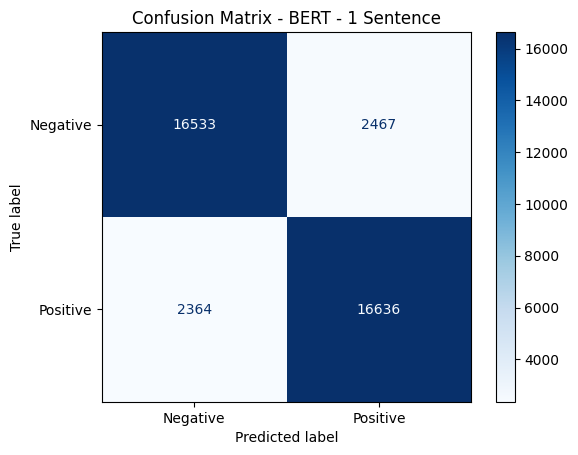

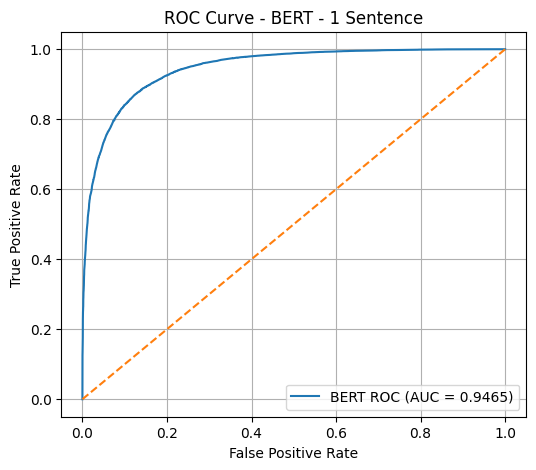

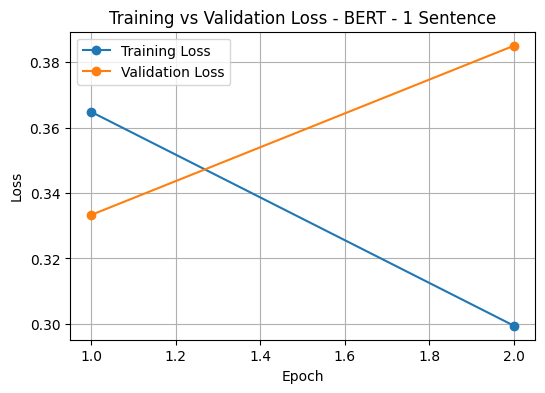

Saved partial results: /content/drive/MyDrive/yelp_textrank_classification_outputs/bert_textrank_results_partial.csv

RUNNING: BERT | Summarised Text | TextRank | 3 Sentences


Token indices sequence length is longer than the specified maximum sequence length for this model (520 > 512). Running this sequence through the model will result in indexing errors



=== TOKEN / TRUNCATION STATS ===
Train avg tokens before trunc: 70.73
Train avg tokens after trunc: 70.15
Train truncation %: 0.64
Validation avg tokens after trunc: 69.94
Test avg tokens after trunc: 70.2
Test truncation %: 0.59


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.234134,0.221912,0.942089,0.936770,0.948179,0.942440,0.986267
2,0.153084,0.226715,0.947143,0.946028,0.948393,0.947209,0.988094


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


=== RESULTS ===
Accuracy: 0.9466
Precision: 0.9457
Recall: 0.9475
F1: 0.9466
ROC-AUC: 0.9882
Training time: 113 min 14.40 sec
Training time per epoch: 56 min 37.20 sec
Inference time: 1 min 20.71 sec
Inference latency per sample (ms): 2.1238
Training throughput (samples/sec): 74.18
Inference throughput (samples/sec): 470.85
Peak training GPU memory (MB): 2331.29
Peak inference GPU memory (MB): 1537.31

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.95      0.95      0.95     19000
    Positive       0.95      0.95      0.95     19000

    accuracy                           0.95     38000
   macro avg       0.95      0.95      0.95     38000
weighted avg       0.95      0.95      0.95     38000



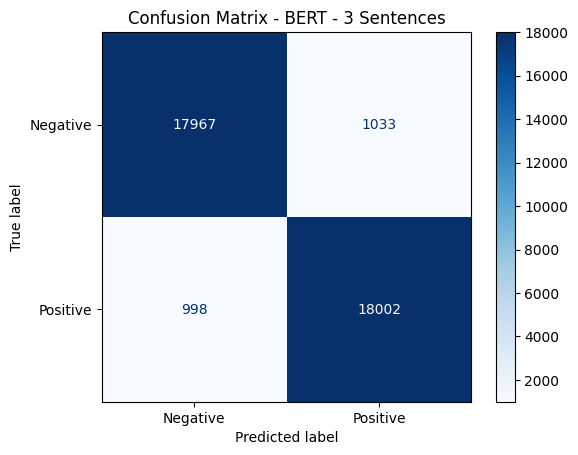

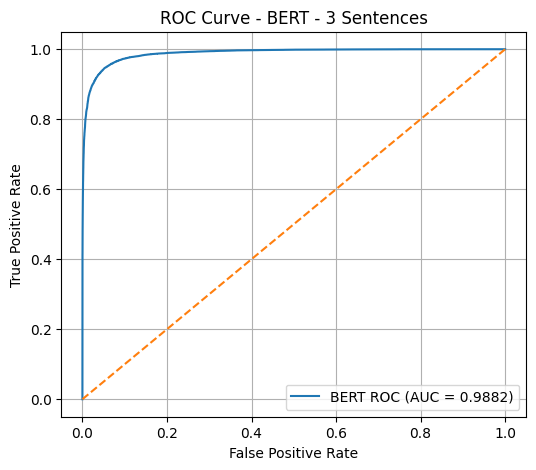

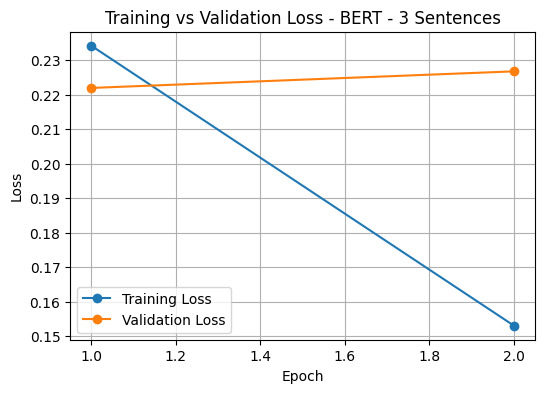

Saved partial results: /content/drive/MyDrive/yelp_textrank_classification_outputs/bert_textrank_results_partial.csv

RUNNING: BERT | Summarised Text | TextRank | 5 Sentences


Token indices sequence length is longer than the specified maximum sequence length for this model (621 > 512). Running this sequence through the model will result in indexing errors



=== TOKEN / TRUNCATION STATS ===
Train avg tokens before trunc: 101.96
Train avg tokens after trunc: 100.38
Train truncation %: 2.12
Validation avg tokens after trunc: 100.16
Test avg tokens after trunc: 100.49
Test truncation %: 2.11


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.182282,0.170442,0.959589,0.954092,0.965643,0.959832,0.992761
2,0.105081,0.166016,0.963375,0.965653,0.960929,0.963285,0.993910


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


=== RESULTS ===
Accuracy: 0.9647
Precision: 0.9667
Recall: 0.9627
F1: 0.9647
ROC-AUC: 0.9941
Training time: 119 min 4.55 sec
Training time per epoch: 59 min 32.28 sec
Inference time: 1 min 23.82 sec
Inference latency per sample (ms): 2.2059
Training throughput (samples/sec): 70.54
Inference throughput (samples/sec): 453.33
Peak training GPU memory (MB): 2329.25
Peak inference GPU memory (MB): 1529.16

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.96      0.97      0.96     19000
    Positive       0.97      0.96      0.96     19000

    accuracy                           0.96     38000
   macro avg       0.96      0.96      0.96     38000
weighted avg       0.96      0.96      0.96     38000



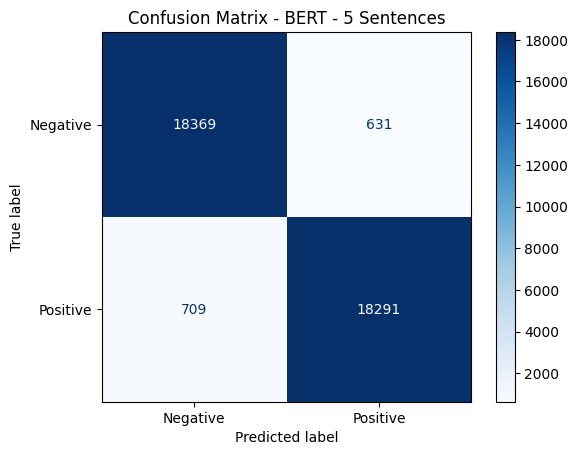

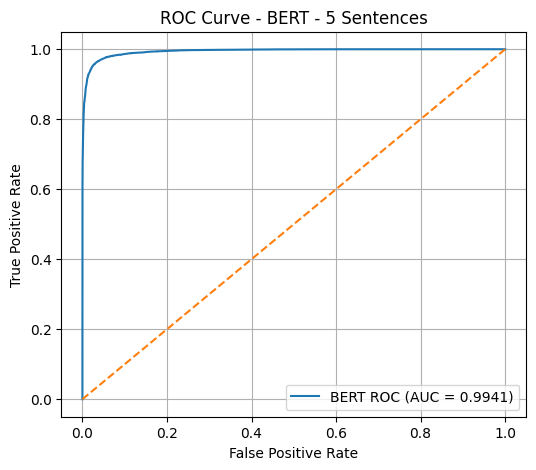

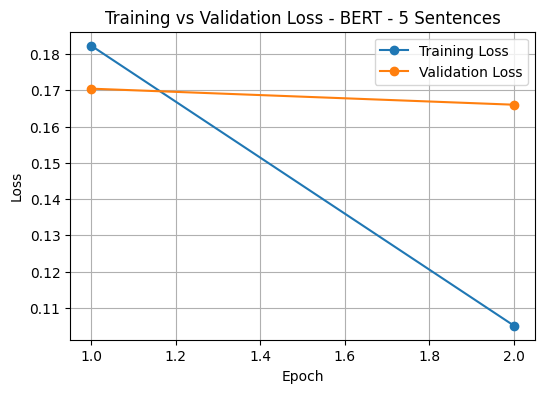

Saved partial results: /content/drive/MyDrive/yelp_textrank_classification_outputs/bert_textrank_results_partial.csv

RUNNING: BERT | Summarised Text | TextRank | 7 Sentences


Token indices sequence length is longer than the specified maximum sequence length for this model (660 > 512). Running this sequence through the model will result in indexing errors



=== TOKEN / TRUNCATION STATS ===
Train avg tokens before trunc: 123.89
Train avg tokens after trunc: 120.21
Train truncation %: 5.3
Validation avg tokens after trunc: 120.04
Test avg tokens after trunc: 120.25
Test truncation %: 5.25


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.161417,0.129975,0.966643,0.967511,0.965714,0.966612,0.994834
2,0.088946,0.140760,0.969714,0.969949,0.969464,0.969707,0.995591


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


=== RESULTS ===
Accuracy: 0.9706
Precision: 0.9711
Recall: 0.97
F1: 0.9706
ROC-AUC: 0.9958
Training time: 120 min 25.44 sec
Training time per epoch: 60 min 12.72 sec
Inference time: 1 min 24.31 sec
Inference latency per sample (ms): 2.2187
Training throughput (samples/sec): 69.75
Inference throughput (samples/sec): 450.72
Peak training GPU memory (MB): 2316.78
Peak inference GPU memory (MB): 1531.22

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.97      0.97      0.97     19000
    Positive       0.97      0.97      0.97     19000

    accuracy                           0.97     38000
   macro avg       0.97      0.97      0.97     38000
weighted avg       0.97      0.97      0.97     38000



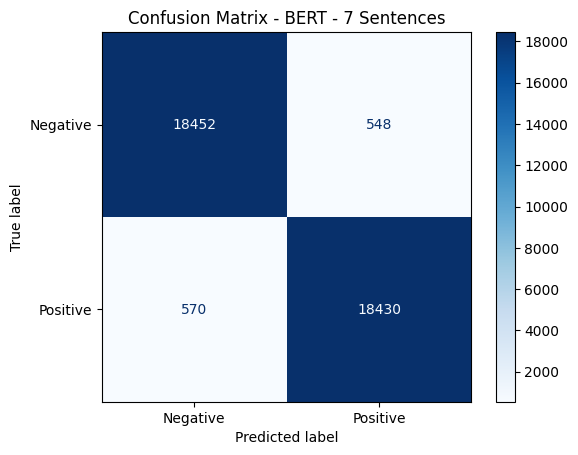

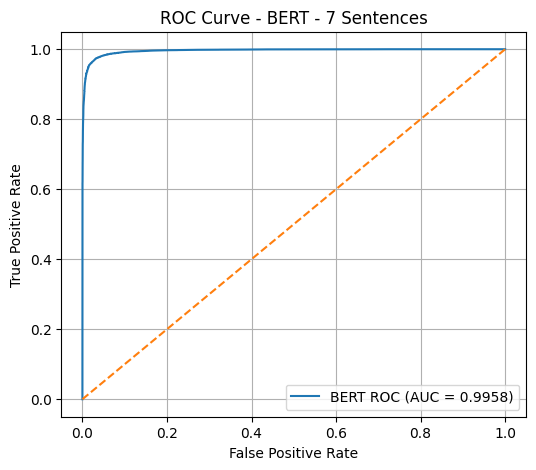

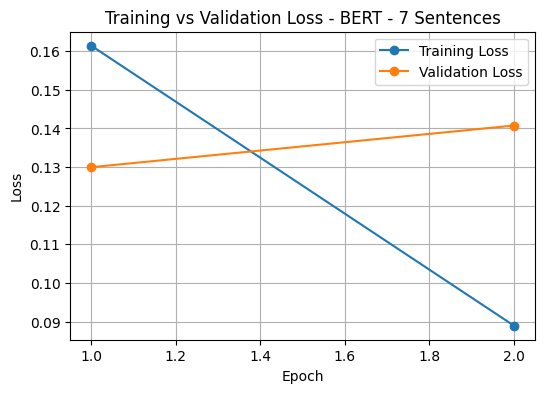

Saved partial results: /content/drive/MyDrive/yelp_textrank_classification_outputs/bert_textrank_results_partial.csv

FINAL BERT TEXTRANK CLASSIFICATION RESULTS


,Input Type,Summary Method,Summary Length,Model,Checkpoint,Optimizer,Max Length,Batch Size,Epochs,Learning Rate,...,Test Truncation %,Training Time (min),Training Time per Epoch (min),Inference Time (sec),Inference Latency per Sample (ms),Training Throughput (samples/sec),Inference Throughput (samples/sec),Peak Training GPU Memory (MB),Peak Inference GPU Memory (MB),Device
0,Summarised Text,TextRank,1 Sentence,BERT,bert-base-uncased,AdamW,256,8,2,0.00002,...,0.09,106.80,53.40,74.15,1.9514,78.65,512.45,2323.52,1529.30,NVIDIA A100-SXM4-40GB
1,Summarised Text,TextRank,3 Sentences,BERT,bert-base-uncased,AdamW,256,8,2,0.00002,...,0.59,113.24,56.62,80.71,2.1238,74.18,470.85,2331.29,1537.31,NVIDIA A100-SXM4-40GB
2,Summarised Text,TextRank,5 Sentences,BERT,bert-base-uncased,AdamW,256,8,2,0.00002,...,2.11,119.08,59.54,83.82,2.2059,70.54,453.33,2329.25,1529.16,NVIDIA A100-SXM4-40GB
3,Summarised Text,TextRank,7 Sentences,BERT,bert-base-uncased,AdamW,256,8,2,0.00002,...,5.25,120.42,60.21,84.31,2.2187,69.75,450.72,2316.78,1531.22,NVIDIA A100-SXM4-40GB



Saved: /content/drive/MyDrive/yelp_textrank_classification_outputs/bert_textrank_results_final.csv


In [ ]:
# =====================================================
# PART 2: YELP TEXTRANK SUMMARY CLASSIFICATION
# BERT ONLY + RESUME SUPPORT
# READ FROM GOOGLE DRIVE
# INPUTS: 1, 3, 5, 7 SENTENCE SUMMARIES
# =====================================================

!pip install -q pandas numpy matplotlib scikit-learn transformers datasets sentencepiece accelerate torch

import os
import gc
import re
import time
import random
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    set_seed
)

from google.colab import drive
drive.mount('/content/drive')

warnings.filterwarnings("ignore")

# -------------------------
# REPRODUCIBILITY
# -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
print("Device:", device_name)

# -------------------------
# PATHS
# -------------------------
BASE_DIR = "/content/drive/MyDrive/yelp_textrank_outputs"
RUN_OUTPUT_DIR = "/content/drive/MyDrive/yelp_textrank_classification_outputs"
os.makedirs(RUN_OUTPUT_DIR, exist_ok=True)

MODEL_LABEL = "BERT"
MODEL_NAME = "bert-base-uncased"

PARTIAL_RESULTS_PATH = os.path.join(RUN_OUTPUT_DIR, "bert_textrank_results_partial.csv")
FINAL_RESULTS_PATH = os.path.join(RUN_OUTPUT_DIR, "bert_textrank_results_final.csv")

print("Reading files from:", BASE_DIR)
print("Saving outputs to:", RUN_OUTPUT_DIR)

# -------------------------
# HYPERPARAMETERS
# -------------------------
MAX_LENGTH = 256
EPOCHS = 2
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
BATCH_SIZE = 8
EARLY_STOPPING_PATIENCE = 1
OPTIMIZER_NAME = "AdamW"

# -------------------------
# DATASET CLASS
# -------------------------
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

# -------------------------
# METRICS
# -------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "roc_auc": roc_auc_score(labels, probs)
    }

# -------------------------
# UTILITIES
# -------------------------
def clean_text(text: str) -> str:
    if pd.isna(text):
        return ""
    text = str(text)
    text = text.replace("<br />", " ")
    text = text.replace("\n", " ")
    text = text.replace("\t", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

def reset_gpu_memory():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

def get_peak_gpu_memory_mb():
    if torch.cuda.is_available():
        return torch.cuda.max_memory_allocated() / (1024 ** 2)
    return None

def format_seconds(seconds: float) -> str:
    if seconds < 60:
        return f"{seconds:.2f} sec"
    minutes = int(seconds // 60)
    rem = seconds % 60
    return f"{minutes} min {rem:.2f} sec"

@dataclass
class TokenStats:
    avg_tokens_before: float
    avg_tokens_after: float
    max_tokens_before: int
    truncated_count: int
    truncation_pct: float

def get_token_stats(texts, tokenizer, max_length=256, batch_size=512):
    full_lengths = []
    trunc_lengths = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]

        full_batch = tokenizer(
            batch,
            add_special_tokens=True,
            truncation=False,
            padding=False
        )

        trunc_batch = tokenizer(
            batch,
            truncation=True,
            padding=False,
            max_length=max_length
        )

        full_lengths.extend([len(x) for x in full_batch["input_ids"]])
        trunc_lengths.extend([len(x) for x in trunc_batch["input_ids"]])

    truncated_count = sum(1 for x in full_lengths if x > max_length)

    stats = TokenStats(
        avg_tokens_before=float(np.mean(full_lengths)),
        avg_tokens_after=float(np.mean(trunc_lengths)),
        max_tokens_before=int(np.max(full_lengths)),
        truncated_count=int(truncated_count),
        truncation_pct=float(truncated_count / len(full_lengths) * 100)
    )

    trunc_enc = tokenizer(
        texts,
        truncation=True,
        padding=False,
        max_length=max_length
    )

    return stats, trunc_enc

def plot_confusion_matrix_save(y_true, y_pred, title, cmap, save_path):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Negative", "Positive"]
    )
    disp.plot(cmap=cmap)
    plt.title(title)
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close()
    return cm

def plot_roc_curve_save(y_true, y_prob, title, label_name, save_path):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc_value = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"{label_name} (AUC = {roc_auc_value:.4f})")
    plt.plot([0, 1], [0, 1], "--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close()

def plot_train_val_loss_save(trainer, title, save_path):
    history = trainer.state.log_history
    train_loss = []
    val_loss = []
    train_epochs = []
    val_epochs = []

    for log in history:
        if "loss" in log and "epoch" in log and "eval_loss" not in log:
            train_loss.append(log["loss"])
            train_epochs.append(log["epoch"])
        if "eval_loss" in log and "epoch" in log:
            val_loss.append(log["eval_loss"])
            val_epochs.append(log["epoch"])

    if len(train_loss) == 0 or len(val_loss) == 0:
        print("Skipping loss plot: insufficient log history.")
        return

    plt.figure(figsize=(6, 4))
    plt.plot(train_epochs, train_loss, marker="o", label="Training Loss")
    plt.plot(val_epochs, val_loss, marker="o", label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close()

# -------------------------
# LOAD SUMMARY CSV FILES
# -------------------------
def load_summary_split(train_path, val_path, test_path):
    train_df = pd.read_csv(train_path)
    val_df = pd.read_csv(val_path)
    test_df = pd.read_csv(test_path)

    for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
        if "summary_text" not in df.columns or "label" not in df.columns:
            raise ValueError(f"{name} file must contain columns: summary_text, label")

    train_texts = train_df["summary_text"].fillna("").astype(str).apply(clean_text).tolist()
    val_texts = val_df["summary_text"].fillna("").astype(str).apply(clean_text).tolist()
    test_texts = test_df["summary_text"].fillna("").astype(str).apply(clean_text).tolist()

    train_labels = train_df["label"].astype(int).tolist()
    val_labels = val_df["label"].astype(int).tolist()
    test_labels = test_df["label"].astype(int).tolist()

    return train_texts, val_texts, test_texts, train_labels, val_labels, test_labels

# -------------------------
# RESUME HELPERS
# -------------------------
def load_partial_results():
    if os.path.exists(PARTIAL_RESULTS_PATH):
        df = pd.read_csv(PARTIAL_RESULTS_PATH)
        print(f"Loaded partial results: {len(df)} completed runs")
        return df
    return pd.DataFrame()

def is_completed(partial_df, summary_length):
    if partial_df.empty:
        return False
    mask = (
        (partial_df["Model"] == MODEL_LABEL) &
        (partial_df["Summary Method"] == "TextRank") &
        (partial_df["Summary Length"] == summary_length)
    )
    return mask.any()

def append_partial_result(result_row):
    if os.path.exists(PARTIAL_RESULTS_PATH):
        prev = pd.read_csv(PARTIAL_RESULTS_PATH)
        updated = pd.concat([prev, pd.DataFrame([result_row])], ignore_index=True)
    else:
        updated = pd.DataFrame([result_row])

    updated.to_csv(PARTIAL_RESULTS_PATH, index=False)
    print(f"Saved partial results: {PARTIAL_RESULTS_PATH}")

# -------------------------
# EXPERIMENT FUNCTION
# -------------------------
def run_experiment(
    summary_method,
    summary_length,
    train_texts,
    val_texts,
    test_texts,
    train_labels,
    val_labels,
    test_labels,
    output_dir,
    max_length=256,
    batch_size=8
):
    os.makedirs(output_dir, exist_ok=True)

    print(f"\n{'='*80}")
    print(f"RUNNING: {MODEL_LABEL} | Summarised Text | {summary_method} | {summary_length}")
    print(f"{'='*80}")

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

    train_stats, train_enc = get_token_stats(train_texts, tokenizer, max_length=max_length)
    val_stats, val_enc = get_token_stats(val_texts, tokenizer, max_length=max_length)
    test_stats, test_enc = get_token_stats(test_texts, tokenizer, max_length=max_length)

    print("\n=== TOKEN / TRUNCATION STATS ===")
    print("Train avg tokens before trunc:", round(train_stats.avg_tokens_before, 2))
    print("Train avg tokens after trunc:", round(train_stats.avg_tokens_after, 2))
    print("Train truncation %:", round(train_stats.truncation_pct, 2))
    print("Validation avg tokens after trunc:", round(val_stats.avg_tokens_after, 2))
    print("Test avg tokens after trunc:", round(test_stats.avg_tokens_after, 2))
    print("Test truncation %:", round(test_stats.truncation_pct, 2))

    train_dataset = TextDataset(train_enc, train_labels)
    val_dataset = TextDataset(val_enc, val_labels)
    test_dataset = TextDataset(test_enc, test_labels)

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

    args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        save_total_limit=1,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=EPOCHS,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        fp16=torch.cuda.is_available(),
        report_to="none",
        seed=SEED,
        optim="adamw_torch"
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        data_collator=data_collator,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)]
    )

    reset_gpu_memory()
    train_start = time.time()
    trainer.train()
    train_time = time.time() - train_start
    peak_train_mem = get_peak_gpu_memory_mb()

    reset_gpu_memory()
    infer_start = time.time()
    pred = trainer.predict(test_dataset)
    infer_time = time.time() - infer_start
    peak_infer_mem = get_peak_gpu_memory_mb()

    y_true = np.array(test_labels)
    y_pred = np.argmax(pred.predictions, axis=1)
    y_prob = torch.softmax(torch.tensor(pred.predictions), dim=1)[:, 1].numpy()

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc_value = roc_auc_score(y_true, y_prob)

    num_train = len(train_dataset)
    num_test = len(test_dataset)

    train_time_per_epoch = train_time / int(args.num_train_epochs)
    train_samples_per_sec = num_train / train_time
    infer_samples_per_sec = num_test / infer_time
    infer_latency_per_sample_ms = (infer_time / num_test) * 1000

    print("\n=== RESULTS ===")
    print("Accuracy:", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall:", round(rec, 4))
    print("F1:", round(f1, 4))
    print("ROC-AUC:", round(roc_auc_value, 4))
    print("Training time:", format_seconds(train_time))
    print("Training time per epoch:", format_seconds(train_time_per_epoch))
    print("Inference time:", format_seconds(infer_time))
    print("Inference latency per sample (ms):", round(infer_latency_per_sample_ms, 4))
    print("Training throughput (samples/sec):", round(train_samples_per_sec, 2))
    print("Inference throughput (samples/sec):", round(infer_samples_per_sec, 2))
    print("Peak training GPU memory (MB):", round(peak_train_mem, 2) if peak_train_mem is not None else "N/A")
    print("Peak inference GPU memory (MB):", round(peak_infer_mem, 2) if peak_infer_mem is not None else "N/A")

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=["Negative", "Positive"],
        zero_division=0,
        output_dict=True
    )

    print("\n=== CLASSIFICATION REPORT ===")
    print(classification_report(
        y_true,
        y_pred,
        target_names=["Negative", "Positive"],
        zero_division=0
    ))

    prefix = f"{MODEL_LABEL.lower()}_{summary_length.replace(' ', '_').lower()}"

    cm_path = os.path.join(output_dir, f"{prefix}_confusion_matrix.png")
    roc_path = os.path.join(output_dir, f"{prefix}_roc_curve.png")
    loss_path = os.path.join(output_dir, f"{prefix}_train_val_loss.png")

    cm = plot_confusion_matrix_save(
        y_true, y_pred,
        f"Confusion Matrix - {MODEL_LABEL} - {summary_length}",
        "Blues",
        cm_path
    )

    plot_roc_curve_save(
        y_true, y_prob,
        f"ROC Curve - {MODEL_LABEL} - {summary_length}",
        f"{MODEL_LABEL} ROC",
        roc_path
    )

    plot_train_val_loss_save(
        trainer,
        f"Training vs Validation Loss - {MODEL_LABEL} - {summary_length}",
        loss_path
    )

    pd.DataFrame(report_dict).transpose().to_csv(
        os.path.join(output_dir, f"{prefix}_classification_report.csv")
    )

    pd.DataFrame(
        cm,
        index=["Actual_Negative", "Actual_Positive"],
        columns=["Pred_Negative", "Pred_Positive"]
    ).to_csv(
        os.path.join(output_dir, f"{prefix}_confusion_matrix_values.csv")
    )

    pd.DataFrame(trainer.state.log_history).to_csv(
        os.path.join(output_dir, f"{prefix}_training_log_history.csv"),
        index=False
    )

    pd.DataFrame({
        "true_label": y_true,
        "pred_label": y_pred,
        "prob_positive": y_prob
    }).to_csv(
        os.path.join(output_dir, f"{prefix}_test_predictions.csv"),
        index=False
    )

    results = {
        "Input Type": "Summarised Text",
        "Summary Method": summary_method,
        "Summary Length": summary_length,
        "Model": MODEL_LABEL,
        "Checkpoint": MODEL_NAME,
        "Optimizer": OPTIMIZER_NAME,
        "Max Length": max_length,
        "Batch Size": batch_size,
        "Epochs": EPOCHS,
        "Learning Rate": LEARNING_RATE,
        "Weight Decay": WEIGHT_DECAY,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1": round(f1, 4),
        "ROC-AUC": round(roc_auc_value, 4),
        "Train Samples": num_train,
        "Validation Samples": len(val_dataset),
        "Test Samples": num_test,
        "Avg Train Tokens Before Trunc": round(train_stats.avg_tokens_before, 2),
        "Avg Train Tokens After Trunc": round(train_stats.avg_tokens_after, 2),
        "Avg Test Tokens Before Trunc": round(test_stats.avg_tokens_before, 2),
        "Avg Test Tokens After Trunc": round(test_stats.avg_tokens_after, 2),
        "Train Truncated Count": train_stats.truncated_count,
        "Test Truncated Count": test_stats.truncated_count,
        "Train Truncation %": round(train_stats.truncation_pct, 2),
        "Test Truncation %": round(test_stats.truncation_pct, 2),
        "Training Time (min)": round(train_time / 60, 2),
        "Training Time per Epoch (min)": round(train_time_per_epoch / 60, 2),
        "Inference Time (sec)": round(infer_time, 2),
        "Inference Latency per Sample (ms)": round(infer_latency_per_sample_ms, 4),
        "Training Throughput (samples/sec)": round(train_samples_per_sec, 2),
        "Inference Throughput (samples/sec)": round(infer_samples_per_sec, 2),
        "Peak Training GPU Memory (MB)": round(peak_train_mem, 2) if peak_train_mem is not None else None,
        "Peak Inference GPU Memory (MB)": round(peak_infer_mem, 2) if peak_infer_mem is not None else None,
        "Device": device_name
    }

    pd.DataFrame([results]).to_csv(
        os.path.join(output_dir, f"{prefix}_metrics.csv"),
        index=False
    )

    del model, trainer, train_dataset, val_dataset, test_dataset
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return results

# -------------------------
# FILE CONFIGURATION
# -------------------------
summary_configs = [
    {
        "summary_length": "1 Sentence",
        "train_path": f"{BASE_DIR}/train_textrank_1_sentences.csv",
        "val_path": f"{BASE_DIR}/val_textrank_1_sentences.csv",
        "test_path": f"{BASE_DIR}/test_textrank_1_sentences.csv",
    },
    {
        "summary_length": "3 Sentences",
        "train_path": f"{BASE_DIR}/train_textrank_3_sentences.csv",
        "val_path": f"{BASE_DIR}/val_textrank_3_sentences.csv",
        "test_path": f"{BASE_DIR}/test_textrank_3_sentences.csv",
    },
    {
        "summary_length": "5 Sentences",
        "train_path": f"{BASE_DIR}/train_textrank_5_sentences.csv",
        "val_path": f"{BASE_DIR}/val_textrank_5_sentences.csv",
        "test_path": f"{BASE_DIR}/test_textrank_5_sentences.csv",
    },
    {
        "summary_length": "7 Sentences",
        "train_path": f"{BASE_DIR}/train_textrank_7_sentences.csv",
        "val_path": f"{BASE_DIR}/val_textrank_7_sentences.csv",
        "test_path": f"{BASE_DIR}/test_textrank_7_sentences.csv",
    }
]

# -------------------------
# CHECK FILES EXIST
# -------------------------
print("\nChecking files...\n")
for config in summary_configs:
    for key in ["train_path", "val_path", "test_path"]:
        print(config[key], "->", os.path.exists(config[key]))

# -------------------------
# RUN WITH RESUME SUPPORT
# -------------------------
partial_df = load_partial_results()
all_results = [] if partial_df.empty else partial_df.to_dict(orient="records")

for config in summary_configs:
    summary_length = config["summary_length"]

    if is_completed(partial_df, summary_length):
        print(f"\nSkipping completed run: {MODEL_LABEL} | TextRank | {summary_length}")
        continue

    train_texts, val_texts, test_texts, train_labels, val_labels, test_labels = load_summary_split(
        config["train_path"],
        config["val_path"],
        config["test_path"]
    )

    result = run_experiment(
        summary_method="TextRank",
        summary_length=summary_length,
        train_texts=train_texts,
        val_texts=val_texts,
        test_texts=test_texts,
        train_labels=train_labels,
        val_labels=val_labels,
        test_labels=test_labels,
        output_dir=f"{RUN_OUTPUT_DIR}/bert_textrank_{summary_length.replace(' ', '_').lower()}",
        max_length=MAX_LENGTH,
        batch_size=BATCH_SIZE
    )

    all_results.append(result)
    append_partial_result(result)
    partial_df = pd.read_csv(PARTIAL_RESULTS_PATH)

# -------------------------
# SAVE FINAL RESULTS
# -------------------------
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values(by=["Summary Length"]).reset_index(drop=True)

print("\nFINAL BERT TEXTRANK CLASSIFICATION RESULTS")
display(results_df)

results_df.to_csv(FINAL_RESULTS_PATH, index=False)
print(f"\nSaved: {FINAL_RESULTS_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: NVIDIA A100-SXM4-40GB
Reading files from: /content/drive/MyDrive/yelp_textrank_outputs
Saving outputs to: /content/drive/MyDrive/yelp_textrank_classification_outputs

Checking files...

/content/drive/MyDrive/yelp_textrank_outputs/train_textrank_1_sentences.csv -> True
/content/drive/MyDrive/yelp_textrank_outputs/val_textrank_1_sentences.csv -> True
/content/drive/MyDrive/yelp_textrank_outputs/test_textrank_1_sentences.csv -> True
/content/drive/MyDrive/yelp_textrank_outputs/train_textrank_3_sentences.csv -> True
/content/drive/MyDrive/yelp_textrank_outputs/val_textrank_3_sentences.csv -> True
/content/drive/MyDrive/yelp_textrank_outputs/test_textrank_3_sentences.csv -> True

RUNNING: XLNet | Summarised Text | TextRank | 1 Sentence

=== TOKEN / TRUNCATION STATS ===
Train avg tokens before trunc: 29.2
Train avg tokens after trunc: 29.05
Train truncatio

Loading weights:   0%|          | 0/206 [00:00<?, ?it/s]

XLNetForSequenceClassification LOAD REPORT from: xlnet-base-cased
Key                             | Status     | 
--------------------------------+------------+-
lm_loss.bias                    | UNEXPECTED | 
lm_loss.weight                  | UNEXPECTED | 
logits_proj.bias                | MISSING    | 
sequence_summary.summary.weight | MISSING    | 
logits_proj.weight              | MISSING    | 
sequence_summary.summary.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.377559,0.324870,0.863054,0.835196,0.904607,0.868517,0.941475
2,0.315726,0.365579,0.874161,0.868100,0.882393,0.875188,0.947150


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


=== RESULTS ===
Accuracy: 0.8762
Precision: 0.872
Recall: 0.8818
F1: 0.8769
ROC-AUC: 0.9485
Training time: 170 min 38.81 sec
Training time per epoch: 85 min 19.40 sec
Inference time: 1 min 57.13 sec
Inference latency per sample (ms): 3.0824
Training throughput (samples/sec): 49.22
Inference throughput (samples/sec): 324.42
Peak training GPU memory (MB): 4595.19
Peak inference GPU memory (MB): 3159.24

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.88      0.87      0.88     19000
    Positive       0.87      0.88      0.88     19000

    accuracy                           0.88     38000
   macro avg       0.88      0.88      0.88     38000
weighted avg       0.88      0.88      0.88     38000



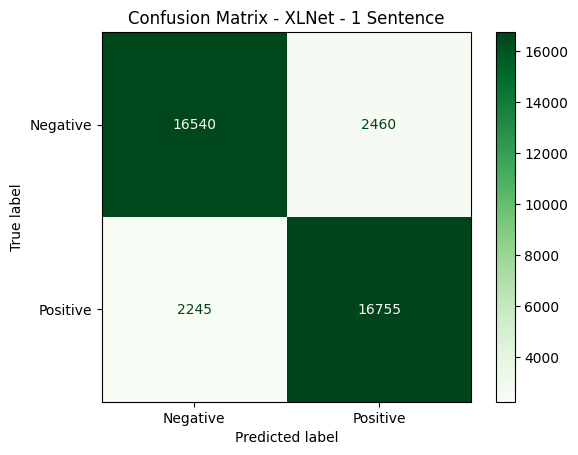

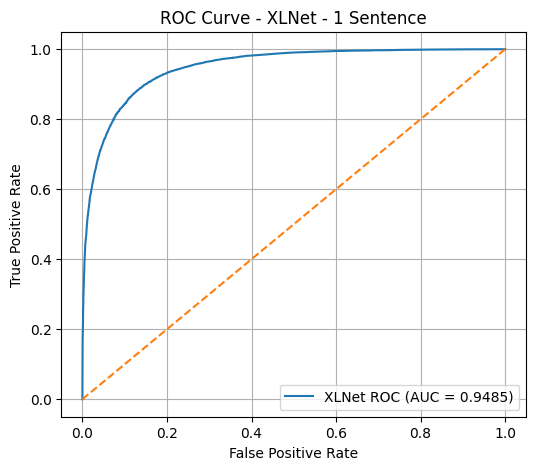

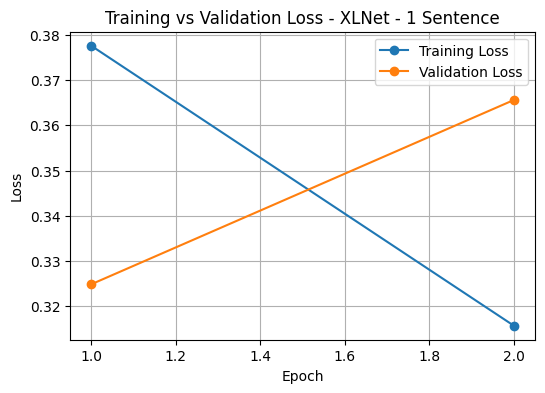

Saved partial results: /content/drive/MyDrive/yelp_textrank_classification_outputs/xlnet_textrank_results_partial_1_3.csv

RUNNING: XLNet | Summarised Text | TextRank | 3 Sentences

=== TOKEN / TRUNCATION STATS ===
Train avg tokens before trunc: 73.36
Train avg tokens after trunc: 72.61
Train truncation %: 0.82
Validation avg tokens after trunc: 72.38
Test avg tokens after trunc: 72.65
Test truncation %: 0.75


Loading weights:   0%|          | 0/206 [00:00<?, ?it/s]

XLNetForSequenceClassification LOAD REPORT from: xlnet-base-cased
Key                             | Status     | 
--------------------------------+------------+-
lm_loss.bias                    | UNEXPECTED | 
lm_loss.weight                  | UNEXPECTED | 
logits_proj.bias                | MISSING    | 
sequence_summary.summary.weight | MISSING    | 
logits_proj.weight              | MISSING    | 
sequence_summary.summary.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.238289,0.212788,0.943679,0.932225,0.956929,0.944415,0.986690
2,0.166136,0.204623,0.950393,0.951199,0.949500,0.950349,0.989161


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


=== RESULTS ===
Accuracy: 0.9504
Precision: 0.9501
Recall: 0.9507
F1: 0.9504
ROC-AUC: 0.9894
Training time: 173 min 59.69 sec
Training time per epoch: 86 min 59.84 sec
Inference time: 2 min 6.17 sec
Inference latency per sample (ms): 3.3202
Training throughput (samples/sec): 48.28
Inference throughput (samples/sec): 301.19
Peak training GPU memory (MB): 4592.13
Peak inference GPU memory (MB): 3150.78

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.95      0.95      0.95     19000
    Positive       0.95      0.95      0.95     19000

    accuracy                           0.95     38000
   macro avg       0.95      0.95      0.95     38000
weighted avg       0.95      0.95      0.95     38000



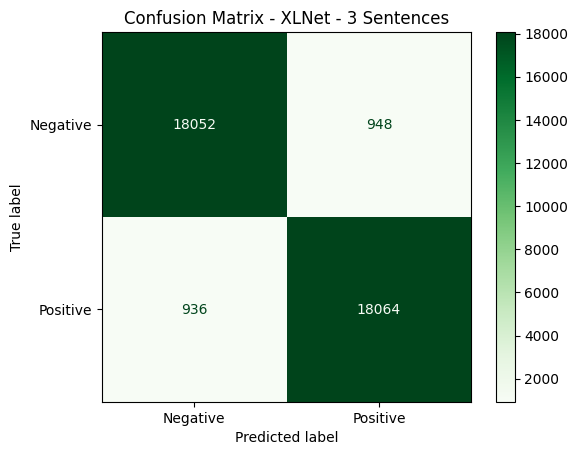

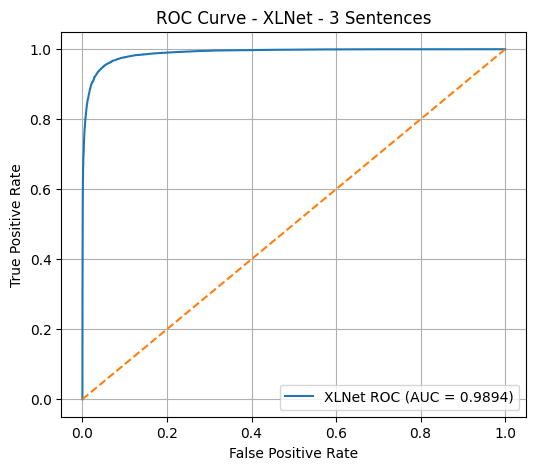

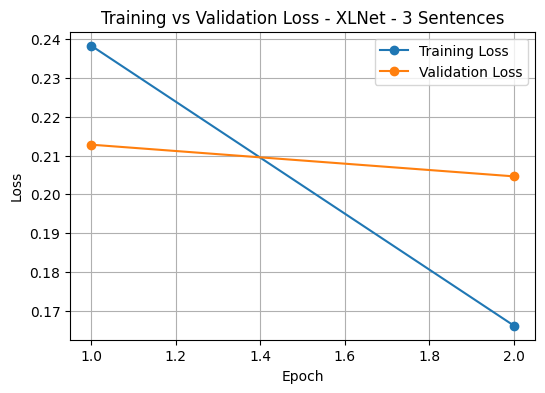

Saved partial results: /content/drive/MyDrive/yelp_textrank_classification_outputs/xlnet_textrank_results_partial_1_3.csv

FINAL XLNET TEXTRANK CLASSIFICATION RESULTS (1 + 3)


,Input Type,Summary Method,Summary Length,Model,Checkpoint,Optimizer,Max Length,Batch Size,Epochs,Learning Rate,...,Test Truncation %,Training Time (min),Training Time per Epoch (min),Inference Time (sec),Inference Latency per Sample (ms),Training Throughput (samples/sec),Inference Throughput (samples/sec),Peak Training GPU Memory (MB),Peak Inference GPU Memory (MB),Device
0,Summarised Text,TextRank,1 Sentence,XLNet,xlnet-base-cased,AdamW,256,8,2,0.00002,...,0.12,170.65,85.32,117.13,3.0824,49.22,324.42,4595.19,3159.24,NVIDIA A100-SXM4-40GB
1,Summarised Text,TextRank,3 Sentences,XLNet,xlnet-base-cased,AdamW,256,8,2,0.00002,...,0.75,173.99,87.00,126.17,3.3202,48.28,301.19,4592.13,3150.78,NVIDIA A100-SXM4-40GB



Saved: /content/drive/MyDrive/yelp_textrank_classification_outputs/xlnet_textrank_results_final_1_3.csv


In [ ]:
# =====================================================
# PART 2: YELP TEXTRANK SUMMARY CLASSIFICATION
# XLNET ONLY + RESUME SUPPORT
# 1 SENTENCE + 3 SENTENCES ONLY
# READ FROM GOOGLE DRIVE
# =====================================================

!pip install -q pandas numpy matplotlib scikit-learn transformers datasets sentencepiece accelerate torch

import os
import gc
import re
import time
import random
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    set_seed
)

from google.colab import drive
drive.mount('/content/drive')

warnings.filterwarnings("ignore")

# -------------------------
# REPRODUCIBILITY
# -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
print("Device:", device_name)

# -------------------------
# PATHS
# -------------------------
BASE_DIR = "/content/drive/MyDrive/yelp_textrank_outputs"
RUN_OUTPUT_DIR = "/content/drive/MyDrive/yelp_textrank_classification_outputs"
os.makedirs(RUN_OUTPUT_DIR, exist_ok=True)

MODEL_LABEL = "XLNet"
MODEL_NAME = "xlnet-base-cased"

PARTIAL_RESULTS_PATH = os.path.join(RUN_OUTPUT_DIR, "xlnet_textrank_results_partial_1_3.csv")
FINAL_RESULTS_PATH = os.path.join(RUN_OUTPUT_DIR, "xlnet_textrank_results_final_1_3.csv")

print("Reading files from:", BASE_DIR)
print("Saving outputs to:", RUN_OUTPUT_DIR)

# -------------------------
# HYPERPARAMETERS
# -------------------------
MAX_LENGTH = 256
EPOCHS = 2
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
BATCH_SIZE = 8
EARLY_STOPPING_PATIENCE = 1
OPTIMIZER_NAME = "AdamW"

# -------------------------
# DATASET CLASS
# -------------------------
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

# -------------------------
# METRICS
# -------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "roc_auc": roc_auc_score(labels, probs)
    }

# -------------------------
# UTILITIES
# -------------------------
def clean_text(text: str) -> str:
    if pd.isna(text):
        return ""
    text = str(text)
    text = text.replace("<br />", " ")
    text = text.replace("\n", " ")
    text = text.replace("\t", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

def reset_gpu_memory():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

def get_peak_gpu_memory_mb():
    if torch.cuda.is_available():
        return torch.cuda.max_memory_allocated() / (1024 ** 2)
    return None

def format_seconds(seconds: float) -> str:
    if seconds < 60:
        return f"{seconds:.2f} sec"
    minutes = int(seconds // 60)
    rem = seconds % 60
    return f"{minutes} min {rem:.2f} sec"

@dataclass
class TokenStats:
    avg_tokens_before: float
    avg_tokens_after: float
    max_tokens_before: int
    truncated_count: int
    truncation_pct: float

def get_token_stats(texts, tokenizer, max_length=256, batch_size=512):
    full_lengths = []
    trunc_lengths = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]

        full_batch = tokenizer(
            batch,
            add_special_tokens=True,
            truncation=False,
            padding=False
        )

        trunc_batch = tokenizer(
            batch,
            truncation=True,
            padding=False,
            max_length=max_length
        )

        full_lengths.extend([len(x) for x in full_batch["input_ids"]])
        trunc_lengths.extend([len(x) for x in trunc_batch["input_ids"]])

    truncated_count = sum(1 for x in full_lengths if x > max_length)

    stats = TokenStats(
        avg_tokens_before=float(np.mean(full_lengths)),
        avg_tokens_after=float(np.mean(trunc_lengths)),
        max_tokens_before=int(np.max(full_lengths)),
        truncated_count=int(truncated_count),
        truncation_pct=float(truncated_count / len(full_lengths) * 100)
    )

    trunc_enc = tokenizer(
        texts,
        truncation=True,
        padding=False,
        max_length=max_length
    )

    return stats, trunc_enc

def plot_confusion_matrix_save(y_true, y_pred, title, cmap, save_path):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Negative", "Positive"]
    )
    disp.plot(cmap=cmap)
    plt.title(title)
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close()
    return cm

def plot_roc_curve_save(y_true, y_prob, title, label_name, save_path):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc_value = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"{label_name} (AUC = {roc_auc_value:.4f})")
    plt.plot([0, 1], [0, 1], "--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close()

def plot_train_val_loss_save(trainer, title, save_path):
    history = trainer.state.log_history
    train_loss = []
    val_loss = []
    train_epochs = []
    val_epochs = []

    for log in history:
        if "loss" in log and "epoch" in log and "eval_loss" not in log:
            train_loss.append(log["loss"])
            train_epochs.append(log["epoch"])
        if "eval_loss" in log and "epoch" in log:
            val_loss.append(log["eval_loss"])
            val_epochs.append(log["epoch"])

    if len(train_loss) == 0 or len(val_loss) == 0:
        print("Skipping loss plot: insufficient log history.")
        return

    plt.figure(figsize=(6, 4))
    plt.plot(train_epochs, train_loss, marker="o", label="Training Loss")
    plt.plot(val_epochs, val_loss, marker="o", label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close()

# -------------------------
# LOAD SUMMARY CSV FILES
# -------------------------
def load_summary_split(train_path, val_path, test_path):
    train_df = pd.read_csv(train_path)
    val_df = pd.read_csv(val_path)
    test_df = pd.read_csv(test_path)

    for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
        if "summary_text" not in df.columns or "label" not in df.columns:
            raise ValueError(f"{name} file must contain columns: summary_text, label")

    train_texts = train_df["summary_text"].fillna("").astype(str).apply(clean_text).tolist()
    val_texts = val_df["summary_text"].fillna("").astype(str).apply(clean_text).tolist()
    test_texts = test_df["summary_text"].fillna("").astype(str).apply(clean_text).tolist()

    train_labels = train_df["label"].astype(int).tolist()
    val_labels = val_df["label"].astype(int).tolist()
    test_labels = test_df["label"].astype(int).tolist()

    return train_texts, val_texts, test_texts, train_labels, val_labels, test_labels

# -------------------------
# RESUME HELPERS
# -------------------------
def load_partial_results():
    if os.path.exists(PARTIAL_RESULTS_PATH):
        df = pd.read_csv(PARTIAL_RESULTS_PATH)
        print(f"Loaded partial results: {len(df)} completed runs")
        return df
    return pd.DataFrame()

def is_completed(partial_df, summary_length):
    if partial_df.empty:
        return False
    mask = (
        (partial_df["Model"] == MODEL_LABEL) &
        (partial_df["Summary Method"] == "TextRank") &
        (partial_df["Summary Length"] == summary_length)
    )
    return mask.any()

def append_partial_result(result_row):
    if os.path.exists(PARTIAL_RESULTS_PATH):
        prev = pd.read_csv(PARTIAL_RESULTS_PATH)
        updated = pd.concat([prev, pd.DataFrame([result_row])], ignore_index=True)
    else:
        updated = pd.DataFrame([result_row])

    updated.to_csv(PARTIAL_RESULTS_PATH, index=False)
    print(f"Saved partial results: {PARTIAL_RESULTS_PATH}")

# -------------------------
# EXPERIMENT FUNCTION
# -------------------------
def run_experiment(
    summary_method,
    summary_length,
    train_texts,
    val_texts,
    test_texts,
    train_labels,
    val_labels,
    test_labels,
    output_dir,
    max_length=256,
    batch_size=8
):
    os.makedirs(output_dir, exist_ok=True)

    print(f"\n{'='*80}")
    print(f"RUNNING: {MODEL_LABEL} | Summarised Text | {summary_method} | {summary_length}")
    print(f"{'='*80}")

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token if tokenizer.eos_token is not None else tokenizer.unk_token

    train_stats, train_enc = get_token_stats(train_texts, tokenizer, max_length=max_length)
    val_stats, val_enc = get_token_stats(val_texts, tokenizer, max_length=max_length)
    test_stats, test_enc = get_token_stats(test_texts, tokenizer, max_length=max_length)

    print("\n=== TOKEN / TRUNCATION STATS ===")
    print("Train avg tokens before trunc:", round(train_stats.avg_tokens_before, 2))
    print("Train avg tokens after trunc:", round(train_stats.avg_tokens_after, 2))
    print("Train truncation %:", round(train_stats.truncation_pct, 2))
    print("Validation avg tokens after trunc:", round(val_stats.avg_tokens_after, 2))
    print("Test avg tokens after trunc:", round(test_stats.avg_tokens_after, 2))
    print("Test truncation %:", round(test_stats.truncation_pct, 2))

    train_dataset = TextDataset(train_enc, train_labels)
    val_dataset = TextDataset(val_enc, val_labels)
    test_dataset = TextDataset(test_enc, test_labels)

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

    if model.config.pad_token_id is None:
        model.config.pad_token_id = tokenizer.pad_token_id

    args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        save_total_limit=1,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=EPOCHS,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        fp16=torch.cuda.is_available(),
        report_to="none",
        seed=SEED,
        optim="adamw_torch"
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        data_collator=data_collator,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)]
    )

    reset_gpu_memory()
    train_start = time.time()
    trainer.train()
    train_time = time.time() - train_start
    peak_train_mem = get_peak_gpu_memory_mb()

    reset_gpu_memory()
    infer_start = time.time()
    pred = trainer.predict(test_dataset)
    infer_time = time.time() - infer_start
    peak_infer_mem = get_peak_gpu_memory_mb()

    y_true = np.array(test_labels)
    y_pred = np.argmax(pred.predictions, axis=1)
    y_prob = torch.softmax(torch.tensor(pred.predictions), dim=1)[:, 1].numpy()

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc_value = roc_auc_score(y_true, y_prob)

    num_train = len(train_dataset)
    num_test = len(test_dataset)

    train_time_per_epoch = train_time / int(args.num_train_epochs)
    train_samples_per_sec = num_train / train_time
    infer_samples_per_sec = num_test / infer_time
    infer_latency_per_sample_ms = (infer_time / num_test) * 1000

    print("\n=== RESULTS ===")
    print("Accuracy:", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall:", round(rec, 4))
    print("F1:", round(f1, 4))
    print("ROC-AUC:", round(roc_auc_value, 4))
    print("Training time:", format_seconds(train_time))
    print("Training time per epoch:", format_seconds(train_time_per_epoch))
    print("Inference time:", format_seconds(infer_time))
    print("Inference latency per sample (ms):", round(infer_latency_per_sample_ms, 4))
    print("Training throughput (samples/sec):", round(train_samples_per_sec, 2))
    print("Inference throughput (samples/sec):", round(infer_samples_per_sec, 2))
    print("Peak training GPU memory (MB):", round(peak_train_mem, 2) if peak_train_mem is not None else "N/A")
    print("Peak inference GPU memory (MB):", round(peak_infer_mem, 2) if peak_infer_mem is not None else "N/A")

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=["Negative", "Positive"],
        zero_division=0,
        output_dict=True
    )

    print("\n=== CLASSIFICATION REPORT ===")
    print(classification_report(
        y_true,
        y_pred,
        target_names=["Negative", "Positive"],
        zero_division=0
    ))

    prefix = f"{MODEL_LABEL.lower()}_{summary_length.replace(' ', '_').lower()}"

    cm_path = os.path.join(output_dir, f"{prefix}_confusion_matrix.png")
    roc_path = os.path.join(output_dir, f"{prefix}_roc_curve.png")
    loss_path = os.path.join(output_dir, f"{prefix}_train_val_loss.png")

    cm = plot_confusion_matrix_save(
        y_true, y_pred,
        f"Confusion Matrix - {MODEL_LABEL} - {summary_length}",
        "Greens",
        cm_path
    )

    plot_roc_curve_save(
        y_true, y_prob,
        f"ROC Curve - {MODEL_LABEL} - {summary_length}",
        f"{MODEL_LABEL} ROC",
        roc_path
    )

    plot_train_val_loss_save(
        trainer,
        f"Training vs Validation Loss - {MODEL_LABEL} - {summary_length}",
        loss_path
    )

    pd.DataFrame(report_dict).transpose().to_csv(
        os.path.join(output_dir, f"{prefix}_classification_report.csv")
    )

    pd.DataFrame(
        cm,
        index=["Actual_Negative", "Actual_Positive"],
        columns=["Pred_Negative", "Pred_Positive"]
    ).to_csv(
        os.path.join(output_dir, f"{prefix}_confusion_matrix_values.csv")
    )

    pd.DataFrame(trainer.state.log_history).to_csv(
        os.path.join(output_dir, f"{prefix}_training_log_history.csv"),
        index=False
    )

    pd.DataFrame({
        "true_label": y_true,
        "pred_label": y_pred,
        "prob_positive": y_prob
    }).to_csv(
        os.path.join(output_dir, f"{prefix}_test_predictions.csv"),
        index=False
    )

    results = {
        "Input Type": "Summarised Text",
        "Summary Method": summary_method,
        "Summary Length": summary_length,
        "Model": MODEL_LABEL,
        "Checkpoint": MODEL_NAME,
        "Optimizer": OPTIMIZER_NAME,
        "Max Length": max_length,
        "Batch Size": batch_size,
        "Epochs": EPOCHS,
        "Learning Rate": LEARNING_RATE,
        "Weight Decay": WEIGHT_DECAY,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1": round(f1, 4),
        "ROC-AUC": round(roc_auc_value, 4),
        "Train Samples": num_train,
        "Validation Samples": len(val_dataset),
        "Test Samples": num_test,
        "Avg Train Tokens Before Trunc": round(train_stats.avg_tokens_before, 2),
        "Avg Train Tokens After Trunc": round(train_stats.avg_tokens_after, 2),
        "Avg Test Tokens Before Trunc": round(test_stats.avg_tokens_before, 2),
        "Avg Test Tokens After Trunc": round(test_stats.avg_tokens_after, 2),
        "Train Truncated Count": train_stats.truncated_count,
        "Test Truncated Count": test_stats.truncated_count,
        "Train Truncation %": round(train_stats.truncation_pct, 2),
        "Test Truncation %": round(test_stats.truncation_pct, 2),
        "Training Time (min)": round(train_time / 60, 2),
        "Training Time per Epoch (min)": round(train_time_per_epoch / 60, 2),
        "Inference Time (sec)": round(infer_time, 2),
        "Inference Latency per Sample (ms)": round(infer_latency_per_sample_ms, 4),
        "Training Throughput (samples/sec)": round(train_samples_per_sec, 2),
        "Inference Throughput (samples/sec)": round(infer_samples_per_sec, 2),
        "Peak Training GPU Memory (MB)": round(peak_train_mem, 2) if peak_train_mem is not None else None,
        "Peak Inference GPU Memory (MB)": round(peak_infer_mem, 2) if peak_infer_mem is not None else None,
        "Device": device_name
    }

    pd.DataFrame([results]).to_csv(
        os.path.join(output_dir, f"{prefix}_metrics.csv"),
        index=False
    )

    del model, trainer, train_dataset, val_dataset, test_dataset
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return results

# -------------------------
# FILE CONFIGURATION
# -------------------------
summary_configs = [
    {
        "summary_length": "1 Sentence",
        "train_path": f"{BASE_DIR}/train_textrank_1_sentences.csv",
        "val_path": f"{BASE_DIR}/val_textrank_1_sentences.csv",
        "test_path": f"{BASE_DIR}/test_textrank_1_sentences.csv",
    },
    {
        "summary_length": "3 Sentences",
        "train_path": f"{BASE_DIR}/train_textrank_3_sentences.csv",
        "val_path": f"{BASE_DIR}/val_textrank_3_sentences.csv",
        "test_path": f"{BASE_DIR}/test_textrank_3_sentences.csv",
    }
]

# -------------------------
# CHECK FILES EXIST
# -------------------------
print("\nChecking files...\n")
for config in summary_configs:
    for key in ["train_path", "val_path", "test_path"]:
        print(config[key], "->", os.path.exists(config[key]))

# -------------------------
# RUN WITH RESUME SUPPORT
# -------------------------
partial_df = load_partial_results()
all_results = [] if partial_df.empty else partial_df.to_dict(orient="records")

for config in summary_configs:
    summary_length = config["summary_length"]

    if is_completed(partial_df, summary_length):
        print(f"\nSkipping completed run: {MODEL_LABEL} | TextRank | {summary_length}")
        continue

    train_texts, val_texts, test_texts, train_labels, val_labels, test_labels = load_summary_split(
        config["train_path"],
        config["val_path"],
        config["test_path"]
    )

    result = run_experiment(
        summary_method="TextRank",
        summary_length=summary_length,
        train_texts=train_texts,
        val_texts=val_texts,
        test_texts=test_texts,
        train_labels=train_labels,
        val_labels=val_labels,
        test_labels=test_labels,
        output_dir=f"{RUN_OUTPUT_DIR}/xlnet_textrank_{summary_length.replace(' ', '_').lower()}",
        max_length=MAX_LENGTH,
        batch_size=BATCH_SIZE
    )

    all_results.append(result)
    append_partial_result(result)
    partial_df = pd.read_csv(PARTIAL_RESULTS_PATH)

# -------------------------
# SAVE FINAL RESULTS
# -------------------------
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values(by=["Summary Length"]).reset_index(drop=True)

print("\nFINAL XLNET TEXTRANK CLASSIFICATION RESULTS (1 + 3)")
display(results_df)

results_df.to_csv(FINAL_RESULTS_PATH, index=False)
print(f"\nSaved: {FINAL_RESULTS_PATH}")

Mounted at /content/drive
Device: NVIDIA A100-SXM4-40GB
Reading files from: /content/drive/MyDrive/yelp_textrank_outputs
Saving outputs to: /content/drive/MyDrive/yelp_textrank_classification_outputs

Checking files...

/content/drive/MyDrive/yelp_textrank_outputs/train_textrank_5_sentences.csv -> True
/content/drive/MyDrive/yelp_textrank_outputs/val_textrank_5_sentences.csv -> True
/content/drive/MyDrive/yelp_textrank_outputs/test_textrank_5_sentences.csv -> True
/content/drive/MyDrive/yelp_textrank_outputs/train_textrank_7_sentences.csv -> True
/content/drive/MyDrive/yelp_textrank_outputs/val_textrank_7_sentences.csv -> True
/content/drive/MyDrive/yelp_textrank_outputs/test_textrank_7_sentences.csv -> True

RUNNING: XLNet | Summarised Text | TextRank | 5 Sentences


config.json:   0%|          | 0.00/760 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


=== TOKEN / TRUNCATION STATS ===
Train avg tokens before trunc: 105.71
Train avg tokens after trunc: 103.67
Train truncation %: 2.57
Validation avg tokens after trunc: 103.43
Test avg tokens after trunc: 103.77
Test truncation %: 2.54


...

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.182769,0.170964,0.961607,0.966809,0.956036,0.961392,0.992822
2,0.114647,0.146338,0.965500,0.964472,0.966607,0.965538,0.994460


model.safetensors:   0%|          | 0.00/467M [00:00<?, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


=== RESULTS ===
Accuracy: 0.9667
Precision: 0.965
Recall: 0.9685
F1: 0.9667
ROC-AUC: 0.9947
Training time: 168 min 25.10 sec
Training time per epoch: 84 min 12.55 sec
Inference time: 2 min 8.96 sec
Inference latency per sample (ms): 3.3936
Training throughput (samples/sec): 49.88
Inference throughput (samples/sec): 294.67
Peak training GPU memory (MB): 3194.05
Peak inference GPU memory (MB): 1761.64

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.97      0.96      0.97     19000
    Positive       0.96      0.97      0.97     19000

    accuracy                           0.97     38000
   macro avg       0.97      0.97      0.97     38000
weighted avg       0.97      0.97      0.97     38000



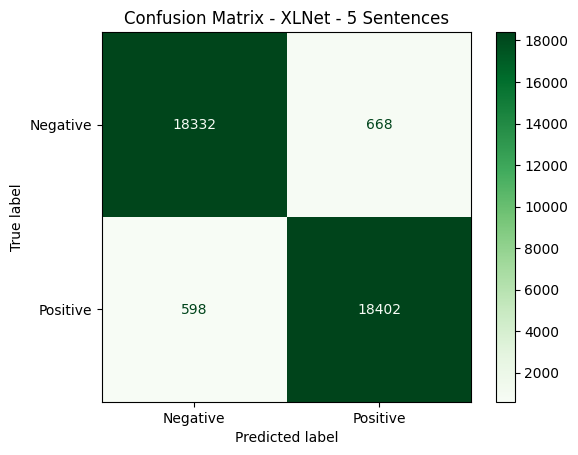

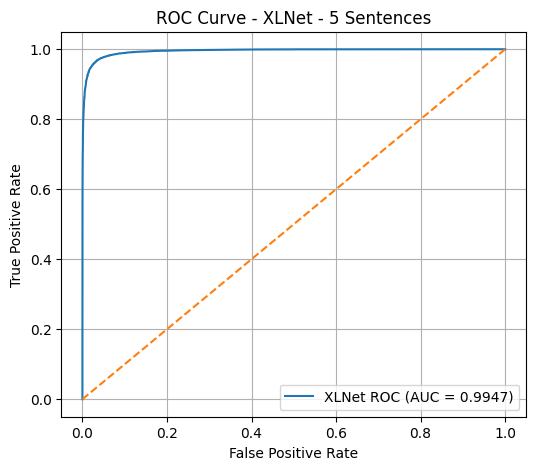

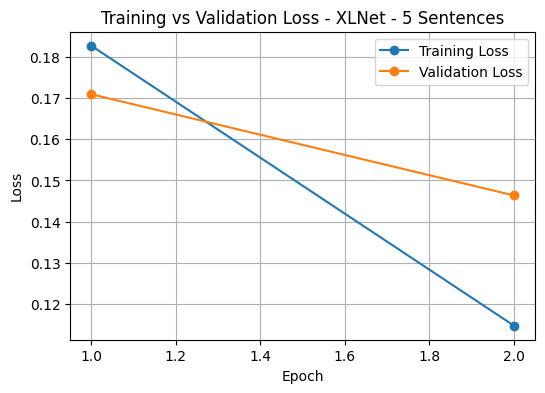

Saved partial results: /content/drive/MyDrive/yelp_textrank_classification_outputs/xlnet_textrank_results_partial_5_7.csv

RUNNING: XLNet | Summarised Text | TextRank | 7 Sentences

=== TOKEN / TRUNCATION STATS ===
Train avg tokens before trunc: 128.42
Train avg tokens after trunc: 123.82
Train truncation %: 6.25
Validation avg tokens after trunc: 123.64
Test avg tokens after trunc: 123.86
Test truncation %: 6.16


Loading weights:   0%|          | 0/206 [00:00<?, ?it/s]

XLNetForSequenceClassification LOAD REPORT from: xlnet-base-cased
Key                             | Status     | 
--------------------------------+------------+-
lm_loss.bias                    | UNEXPECTED | 
lm_loss.weight                  | UNEXPECTED | 
logits_proj.weight              | MISSING    | 
logits_proj.bias                | MISSING    | 
sequence_summary.summary.bias   | MISSING    | 
sequence_summary.summary.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.166791,0.122092,0.967000,0.965239,0.968893,0.967062,0.994992


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.166791,0.122092,0.967000,0.965239,0.968893,0.967062,0.994992
2,0.101969,0.124704,0.971893,0.972568,0.971179,0.971873,0.996020


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


=== RESULTS ===
Accuracy: 0.9714
Precision: 0.9729
Recall: 0.9698
F1: 0.9714
ROC-AUC: 0.9961
Training time: 180 min 15.64 sec
Training time per epoch: 90 min 7.82 sec
Inference time: 2 min 13.14 sec
Inference latency per sample (ms): 3.5036
Training throughput (samples/sec): 46.6
Inference throughput (samples/sec): 285.42
Peak training GPU memory (MB): 3187.9
Peak inference GPU memory (MB): 1755.59

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.97      0.97      0.97     19000
    Positive       0.97      0.97      0.97     19000

    accuracy                           0.97     38000
   macro avg       0.97      0.97      0.97     38000
weighted avg       0.97      0.97      0.97     38000



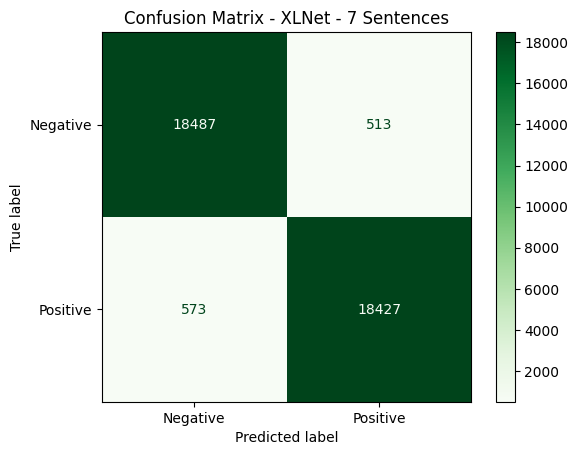

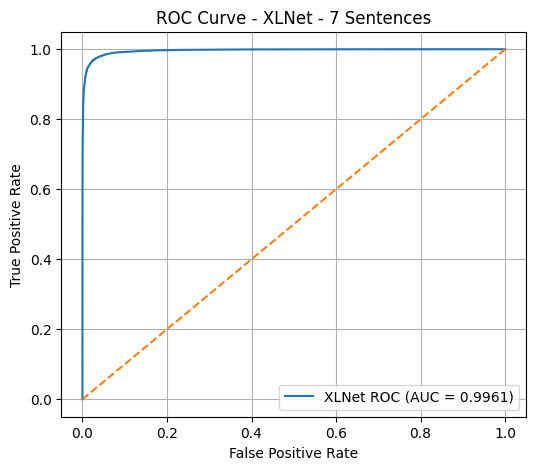

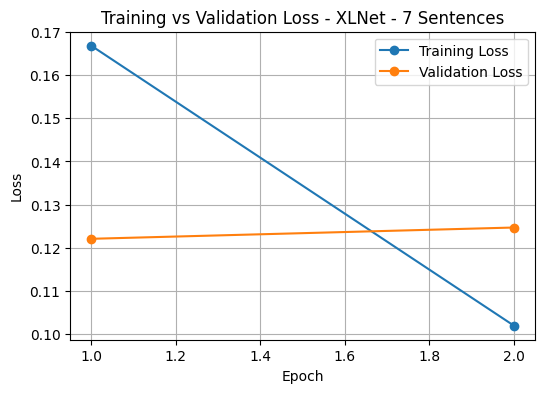

Saved partial results: /content/drive/MyDrive/yelp_textrank_classification_outputs/xlnet_textrank_results_partial_5_7.csv

FINAL XLNET TEXTRANK CLASSIFICATION RESULTS (5 + 7)


,Input Type,Summary Method,Summary Length,Model,Checkpoint,Optimizer,Max Length,Batch Size,Epochs,Learning Rate,...,Test Truncation %,Training Time (min),Training Time per Epoch (min),Inference Time (sec),Inference Latency per Sample (ms),Training Throughput (samples/sec),Inference Throughput (samples/sec),Peak Training GPU Memory (MB),Peak Inference GPU Memory (MB),Device
0,Summarised Text,TextRank,5 Sentences,XLNet,xlnet-base-cased,AdamW,256,8,2,0.00002,...,2.54,168.42,84.21,128.96,3.3936,49.88,294.67,3194.05,1761.64,NVIDIA A100-SXM4-40GB
1,Summarised Text,TextRank,7 Sentences,XLNet,xlnet-base-cased,AdamW,256,8,2,0.00002,...,6.16,180.26,90.13,133.14,3.5036,46.60,285.42,3187.90,1755.59,NVIDIA A100-SXM4-40GB



Saved: /content/drive/MyDrive/yelp_textrank_classification_outputs/xlnet_textrank_results_final_5_7.csv


In [ ]:
# =====================================================
# PART 2: YELP TEXTRANK SUMMARY CLASSIFICATION
# XLNET ONLY + RESUME SUPPORT
# 5 SENTENCES + 7 SENTENCES ONLY
# READ FROM GOOGLE DRIVE
# =====================================================

!pip install -q pandas numpy matplotlib scikit-learn transformers datasets sentencepiece accelerate torch

import os
import gc
import re
import time
import random
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    set_seed
)

from google.colab import drive
drive.mount('/content/drive')

warnings.filterwarnings("ignore")

# -------------------------
# REPRODUCIBILITY
# -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
print("Device:", device_name)

# -------------------------
# PATHS
# -------------------------
BASE_DIR = "/content/drive/MyDrive/yelp_textrank_outputs"
RUN_OUTPUT_DIR = "/content/drive/MyDrive/yelp_textrank_classification_outputs"
os.makedirs(RUN_OUTPUT_DIR, exist_ok=True)

MODEL_LABEL = "XLNet"
MODEL_NAME = "xlnet-base-cased"

PARTIAL_RESULTS_PATH = os.path.join(RUN_OUTPUT_DIR, "xlnet_textrank_results_partial_5_7.csv")
FINAL_RESULTS_PATH = os.path.join(RUN_OUTPUT_DIR, "xlnet_textrank_results_final_5_7.csv")

print("Reading files from:", BASE_DIR)
print("Saving outputs to:", RUN_OUTPUT_DIR)

# -------------------------
# HYPERPARAMETERS
# -------------------------
MAX_LENGTH = 256
EPOCHS = 2
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
BATCH_SIZE = 8
EARLY_STOPPING_PATIENCE = 1
OPTIMIZER_NAME = "AdamW"

# -------------------------
# DATASET CLASS
# -------------------------
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

# -------------------------
# METRICS
# -------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "roc_auc": roc_auc_score(labels, probs)
    }

# -------------------------
# UTILITIES
# -------------------------
def clean_text(text: str) -> str:
    if pd.isna(text):
        return ""
    text = str(text)
    text = text.replace("<br />", " ")
    text = text.replace("\n", " ")
    text = text.replace("\t", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

def reset_gpu_memory():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

def get_peak_gpu_memory_mb():
    if torch.cuda.is_available():
        return torch.cuda.max_memory_allocated() / (1024 ** 2)
    return None

def format_seconds(seconds: float) -> str:
    if seconds < 60:
        return f"{seconds:.2f} sec"
    minutes = int(seconds // 60)
    rem = seconds % 60
    return f"{minutes} min {rem:.2f} sec"

@dataclass
class TokenStats:
    avg_tokens_before: float
    avg_tokens_after: float
    max_tokens_before: int
    truncated_count: int
    truncation_pct: float

def get_token_stats(texts, tokenizer, max_length=256, batch_size=512):
    full_lengths = []
    trunc_lengths = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]

        full_batch = tokenizer(
            batch,
            add_special_tokens=True,
            truncation=False,
            padding=False
        )

        trunc_batch = tokenizer(
            batch,
            truncation=True,
            padding=False,
            max_length=max_length
        )

        full_lengths.extend([len(x) for x in full_batch["input_ids"]])
        trunc_lengths.extend([len(x) for x in trunc_batch["input_ids"]])

    truncated_count = sum(1 for x in full_lengths if x > max_length)

    stats = TokenStats(
        avg_tokens_before=float(np.mean(full_lengths)),
        avg_tokens_after=float(np.mean(trunc_lengths)),
        max_tokens_before=int(np.max(full_lengths)),
        truncated_count=int(truncated_count),
        truncation_pct=float(truncated_count / len(full_lengths) * 100)
    )

    trunc_enc = tokenizer(
        texts,
        truncation=True,
        padding=False,
        max_length=max_length
    )

    return stats, trunc_enc

def plot_confusion_matrix_save(y_true, y_pred, title, cmap, save_path):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Negative", "Positive"]
    )
    disp.plot(cmap=cmap)
    plt.title(title)
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close()
    return cm

def plot_roc_curve_save(y_true, y_prob, title, label_name, save_path):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc_value = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"{label_name} (AUC = {roc_auc_value:.4f})")
    plt.plot([0, 1], [0, 1], "--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close()

def plot_train_val_loss_save(trainer, title, save_path):
    history = trainer.state.log_history
    train_loss = []
    val_loss = []
    train_epochs = []
    val_epochs = []

    for log in history:
        if "loss" in log and "epoch" in log and "eval_loss" not in log:
            train_loss.append(log["loss"])
            train_epochs.append(log["epoch"])
        if "eval_loss" in log and "epoch" in log:
            val_loss.append(log["eval_loss"])
            val_epochs.append(log["epoch"])

    if len(train_loss) == 0 or len(val_loss) == 0:
        print("Skipping loss plot: insufficient log history.")
        return

    plt.figure(figsize=(6, 4))
    plt.plot(train_epochs, train_loss, marker="o", label="Training Loss")
    plt.plot(val_epochs, val_loss, marker="o", label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close()

# -------------------------
# LOAD SUMMARY CSV FILES
# -------------------------
def load_summary_split(train_path, val_path, test_path):
    train_df = pd.read_csv(train_path)
    val_df = pd.read_csv(val_path)
    test_df = pd.read_csv(test_path)

    for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
        if "summary_text" not in df.columns or "label" not in df.columns:
            raise ValueError(f"{name} file must contain columns: summary_text, label")

    train_texts = train_df["summary_text"].fillna("").astype(str).apply(clean_text).tolist()
    val_texts = val_df["summary_text"].fillna("").astype(str).apply(clean_text).tolist()
    test_texts = test_df["summary_text"].fillna("").astype(str).apply(clean_text).tolist()

    train_labels = train_df["label"].astype(int).tolist()
    val_labels = val_df["label"].astype(int).tolist()
    test_labels = test_df["label"].astype(int).tolist()

    return train_texts, val_texts, test_texts, train_labels, val_labels, test_labels

# -------------------------
# RESUME HELPERS
# -------------------------
def load_partial_results():
    if os.path.exists(PARTIAL_RESULTS_PATH):
        df = pd.read_csv(PARTIAL_RESULTS_PATH)
        print(f"Loaded partial results: {len(df)} completed runs")
        return df
    return pd.DataFrame()

def is_completed(partial_df, summary_length):
    if partial_df.empty:
        return False
    mask = (
        (partial_df["Model"] == MODEL_LABEL) &
        (partial_df["Summary Method"] == "TextRank") &
        (partial_df["Summary Length"] == summary_length)
    )
    return mask.any()

def append_partial_result(result_row):
    if os.path.exists(PARTIAL_RESULTS_PATH):
        prev = pd.read_csv(PARTIAL_RESULTS_PATH)
        updated = pd.concat([prev, pd.DataFrame([result_row])], ignore_index=True)
    else:
        updated = pd.DataFrame([result_row])

    updated.to_csv(PARTIAL_RESULTS_PATH, index=False)
    print(f"Saved partial results: {PARTIAL_RESULTS_PATH}")

# -------------------------
# EXPERIMENT FUNCTION
# -------------------------
def run_experiment(
    summary_method,
    summary_length,
    train_texts,
    val_texts,
    test_texts,
    train_labels,
    val_labels,
    test_labels,
    output_dir,
    max_length=256,
    batch_size=8
):
    os.makedirs(output_dir, exist_ok=True)

    print(f"\n{'='*80}")
    print(f"RUNNING: {MODEL_LABEL} | Summarised Text | {summary_method} | {summary_length}")
    print(f"{'='*80}")

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token if tokenizer.eos_token is not None else tokenizer.unk_token

    train_stats, train_enc = get_token_stats(train_texts, tokenizer, max_length=max_length)
    val_stats, val_enc = get_token_stats(val_texts, tokenizer, max_length=max_length)
    test_stats, test_enc = get_token_stats(test_texts, tokenizer, max_length=max_length)

    print("\n=== TOKEN / TRUNCATION STATS ===")
    print("Train avg tokens before trunc:", round(train_stats.avg_tokens_before, 2))
    print("Train avg tokens after trunc:", round(train_stats.avg_tokens_after, 2))
    print("Train truncation %:", round(train_stats.truncation_pct, 2))
    print("Validation avg tokens after trunc:", round(val_stats.avg_tokens_after, 2))
    print("Test avg tokens after trunc:", round(test_stats.avg_tokens_after, 2))
    print("Test truncation %:", round(test_stats.truncation_pct, 2))

    train_dataset = TextDataset(train_enc, train_labels)
    val_dataset = TextDataset(val_enc, val_labels)
    test_dataset = TextDataset(test_enc, test_labels)

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

    if model.config.pad_token_id is None:
        model.config.pad_token_id = tokenizer.pad_token_id

    args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        save_total_limit=1,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=EPOCHS,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        fp16=torch.cuda.is_available(),
        report_to="none",
        seed=SEED,
        optim="adamw_torch"
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        data_collator=data_collator,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)]
    )

    reset_gpu_memory()
    train_start = time.time()
    trainer.train()
    train_time = time.time() - train_start
    peak_train_mem = get_peak_gpu_memory_mb()

    reset_gpu_memory()
    infer_start = time.time()
    pred = trainer.predict(test_dataset)
    infer_time = time.time() - infer_start
    peak_infer_mem = get_peak_gpu_memory_mb()

    y_true = np.array(test_labels)
    y_pred = np.argmax(pred.predictions, axis=1)
    y_prob = torch.softmax(torch.tensor(pred.predictions), dim=1)[:, 1].numpy()

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc_value = roc_auc_score(y_true, y_prob)

    num_train = len(train_dataset)
    num_test = len(test_dataset)

    train_time_per_epoch = train_time / int(args.num_train_epochs)
    train_samples_per_sec = num_train / train_time
    infer_samples_per_sec = num_test / infer_time
    infer_latency_per_sample_ms = (infer_time / num_test) * 1000

    print("\n=== RESULTS ===")
    print("Accuracy:", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall:", round(rec, 4))
    print("F1:", round(f1, 4))
    print("ROC-AUC:", round(roc_auc_value, 4))
    print("Training time:", format_seconds(train_time))
    print("Training time per epoch:", format_seconds(train_time_per_epoch))
    print("Inference time:", format_seconds(infer_time))
    print("Inference latency per sample (ms):", round(infer_latency_per_sample_ms, 4))
    print("Training throughput (samples/sec):", round(train_samples_per_sec, 2))
    print("Inference throughput (samples/sec):", round(infer_samples_per_sec, 2))
    print("Peak training GPU memory (MB):", round(peak_train_mem, 2) if peak_train_mem is not None else "N/A")
    print("Peak inference GPU memory (MB):", round(peak_infer_mem, 2) if peak_infer_mem is not None else "N/A")

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=["Negative", "Positive"],
        zero_division=0,
        output_dict=True
    )

    print("\n=== CLASSIFICATION REPORT ===")
    print(classification_report(
        y_true,
        y_pred,
        target_names=["Negative", "Positive"],
        zero_division=0
    ))

    prefix = f"{MODEL_LABEL.lower()}_{summary_length.replace(' ', '_').lower()}"

    cm_path = os.path.join(output_dir, f"{prefix}_confusion_matrix.png")
    roc_path = os.path.join(output_dir, f"{prefix}_roc_curve.png")
    loss_path = os.path.join(output_dir, f"{prefix}_train_val_loss.png")

    cm = plot_confusion_matrix_save(
        y_true, y_pred,
        f"Confusion Matrix - {MODEL_LABEL} - {summary_length}",
        "Greens",
        cm_path
    )

    plot_roc_curve_save(
        y_true, y_prob,
        f"ROC Curve - {MODEL_LABEL} - {summary_length}",
        f"{MODEL_LABEL} ROC",
        roc_path
    )

    plot_train_val_loss_save(
        trainer,
        f"Training vs Validation Loss - {MODEL_LABEL} - {summary_length}",
        loss_path
    )

    pd.DataFrame(report_dict).transpose().to_csv(
        os.path.join(output_dir, f"{prefix}_classification_report.csv")
    )

    pd.DataFrame(
        cm,
        index=["Actual_Negative", "Actual_Positive"],
        columns=["Pred_Negative", "Pred_Positive"]
    ).to_csv(
        os.path.join(output_dir, f"{prefix}_confusion_matrix_values.csv")
    )

    pd.DataFrame(trainer.state.log_history).to_csv(
        os.path.join(output_dir, f"{prefix}_training_log_history.csv"),
        index=False
    )

    pd.DataFrame({
        "true_label": y_true,
        "pred_label": y_pred,
        "prob_positive": y_prob
    }).to_csv(
        os.path.join(output_dir, f"{prefix}_test_predictions.csv"),
        index=False
    )

    results = {
        "Input Type": "Summarised Text",
        "Summary Method": summary_method,
        "Summary Length": summary_length,
        "Model": MODEL_LABEL,
        "Checkpoint": MODEL_NAME,
        "Optimizer": OPTIMIZER_NAME,
        "Max Length": max_length,
        "Batch Size": batch_size,
        "Epochs": EPOCHS,
        "Learning Rate": LEARNING_RATE,
        "Weight Decay": WEIGHT_DECAY,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1": round(f1, 4),
        "ROC-AUC": round(roc_auc_value, 4),
        "Train Samples": num_train,
        "Validation Samples": len(val_dataset),
        "Test Samples": num_test,
        "Avg Train Tokens Before Trunc": round(train_stats.avg_tokens_before, 2),
        "Avg Train Tokens After Trunc": round(train_stats.avg_tokens_after, 2),
        "Avg Test Tokens Before Trunc": round(test_stats.avg_tokens_before, 2),
        "Avg Test Tokens After Trunc": round(test_stats.avg_tokens_after, 2),
        "Train Truncated Count": train_stats.truncated_count,
        "Test Truncated Count": test_stats.truncated_count,
        "Train Truncation %": round(train_stats.truncation_pct, 2),
        "Test Truncation %": round(test_stats.truncation_pct, 2),
        "Training Time (min)": round(train_time / 60, 2),
        "Training Time per Epoch (min)": round(train_time_per_epoch / 60, 2),
        "Inference Time (sec)": round(infer_time, 2),
        "Inference Latency per Sample (ms)": round(infer_latency_per_sample_ms, 4),
        "Training Throughput (samples/sec)": round(train_samples_per_sec, 2),
        "Inference Throughput (samples/sec)": round(infer_samples_per_sec, 2),
        "Peak Training GPU Memory (MB)": round(peak_train_mem, 2) if peak_train_mem is not None else None,
        "Peak Inference GPU Memory (MB)": round(peak_infer_mem, 2) if peak_infer_mem is not None else None,
        "Device": device_name
    }

    pd.DataFrame([results]).to_csv(
        os.path.join(output_dir, f"{prefix}_metrics.csv"),
        index=False
    )

    del model, trainer, train_dataset, val_dataset, test_dataset
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return results

# -------------------------
# FILE CONFIGURATION
# -------------------------
summary_configs = [
    {
        "summary_length": "5 Sentences",
        "train_path": f"{BASE_DIR}/train_textrank_5_sentences.csv",
        "val_path": f"{BASE_DIR}/val_textrank_5_sentences.csv",
        "test_path": f"{BASE_DIR}/test_textrank_5_sentences.csv",
    },
    {
        "summary_length": "7 Sentences",
        "train_path": f"{BASE_DIR}/train_textrank_7_sentences.csv",
        "val_path": f"{BASE_DIR}/val_textrank_7_sentences.csv",
        "test_path": f"{BASE_DIR}/test_textrank_7_sentences.csv",
    }
]

# -------------------------
# CHECK FILES EXIST
# -------------------------
print("\nChecking files...\n")
for config in summary_configs:
    for key in ["train_path", "val_path", "test_path"]:
        print(config[key], "->", os.path.exists(config[key]))

# -------------------------
# RUN WITH RESUME SUPPORT
# -------------------------
partial_df = load_partial_results()
all_results = [] if partial_df.empty else partial_df.to_dict(orient="records")

for config in summary_configs:
    summary_length = config["summary_length"]

    if is_completed(partial_df, summary_length):
        print(f"\nSkipping completed run: {MODEL_LABEL} | TextRank | {summary_length}")
        continue

    train_texts, val_texts, test_texts, train_labels, val_labels, test_labels = load_summary_split(
        config["train_path"],
        config["val_path"],
        config["test_path"]
    )

    result = run_experiment(
        summary_method="TextRank",
        summary_length=summary_length,
        train_texts=train_texts,
        val_texts=val_texts,
        test_texts=test_texts,
        train_labels=train_labels,
        val_labels=val_labels,
        test_labels=test_labels,
        output_dir=f"{RUN_OUTPUT_DIR}/xlnet_textrank_{summary_length.replace(' ', '_').lower()}",
        max_length=MAX_LENGTH,
        batch_size=BATCH_SIZE
    )

    all_results.append(result)
    append_partial_result(result)
    partial_df = pd.read_csv(PARTIAL_RESULTS_PATH)

# -------------------------
# SAVE FINAL RESULTS
# -------------------------
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values(by=["Summary Length"]).reset_index(drop=True)

print("\nFINAL XLNET TEXTRANK CLASSIFICATION RESULTS (5 + 7)")
display(results_df)

results_df.to_csv(FINAL_RESULTS_PATH, index=False)
print(f"\nSaved: {FINAL_RESULTS_PATH}")